###Subtask 1 and 2 

In [1]:
import sys
import os

# Make sure Python can find your database/ folder
sys.path.insert(0, os.path.abspath('.'))

from database import PerformanceAnalyzer

print("Imports successful.")
print(f"Working directory: {os.getcwd()}")

Imports successful.
Working directory: d:\Module_A



  PERFORMANCE BENCHMARKING
  B+ Tree  vs  BruteForce
  Sizes   : 100 → 99100 (100 points)
  BPT order: 4   |   Seed: 42

[ 1 / 6 ]  Running insertion benchmark ...
         25 / 100 sizes done ...
         50 / 100 sizes done ...
         75 / 100 sizes done ...
         100 / 100 sizes done ...
         Done.

[ 2 / 6 ]  Running search benchmark ...
         25 / 100 sizes done ...
         50 / 100 sizes done ...
         75 / 100 sizes done ...
         100 / 100 sizes done ...
         Done.

[ 3 / 6 ]  Running deletion benchmark ...
         25 / 100 sizes done ...
         50 / 100 sizes done ...
         75 / 100 sizes done ...
         100 / 100 sizes done ...
         Done.

[ 4 / 6 ]  Running range query benchmark ...
         25 / 100 sizes done ...
         50 / 100 sizes done ...
         75 / 100 sizes done ...
         100 / 100 sizes done ...
         Done.

[ 5 / 6 ]  Running random mixed operations benchmark ...
         5 / 20 sizes done ...
         10 / 20 sizes d

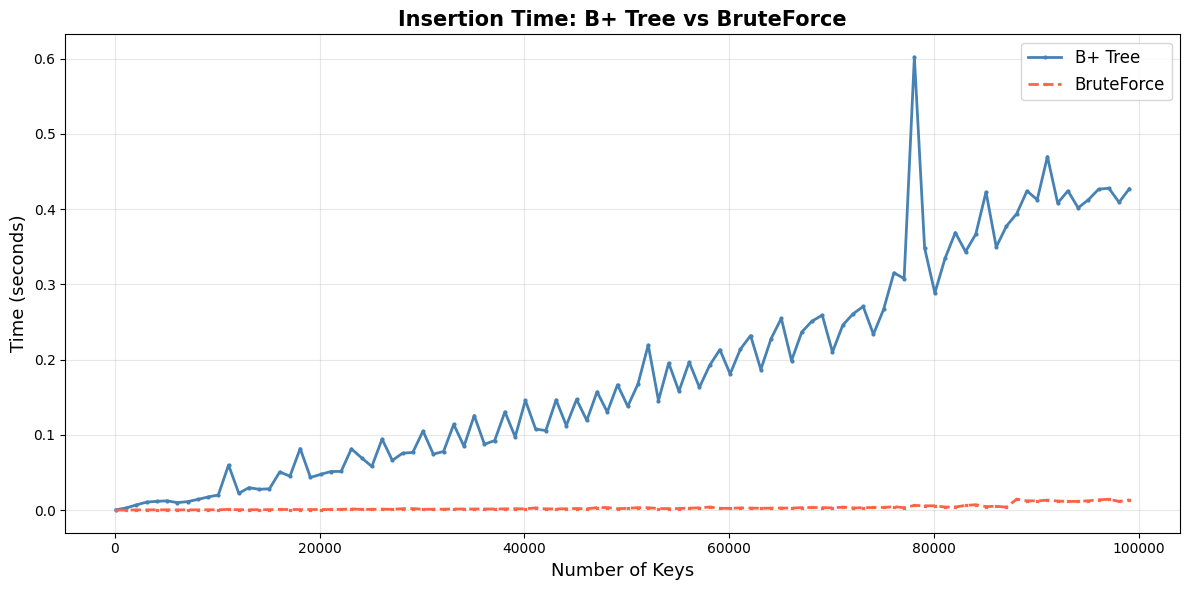

  Saved → graphs/insertion_benchmark.png


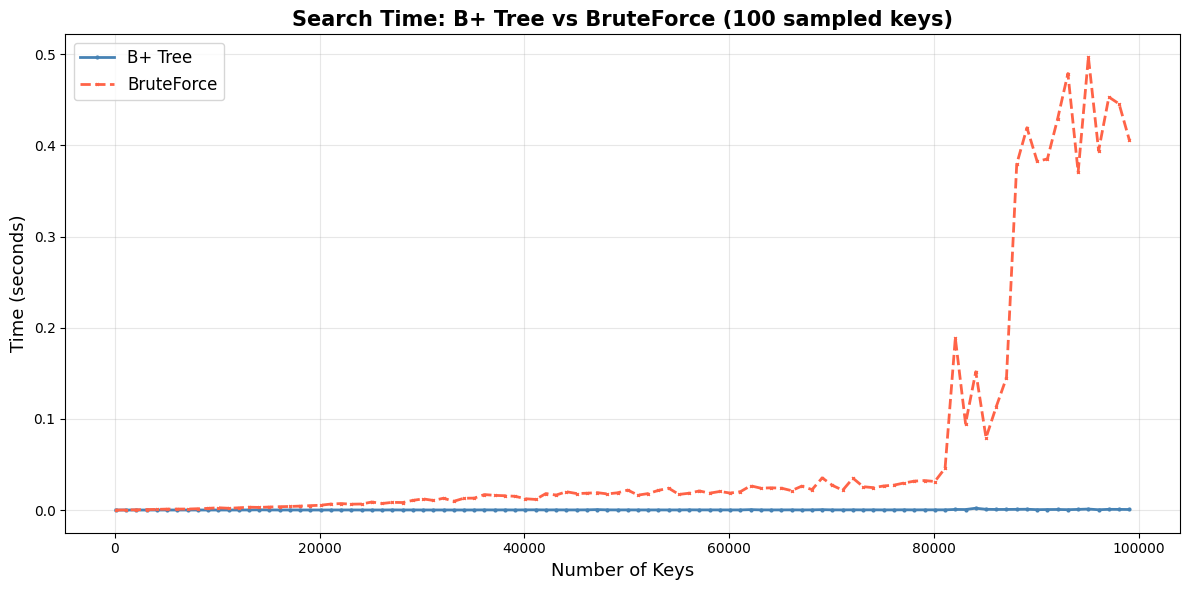

  Saved → graphs/search_benchmark.png


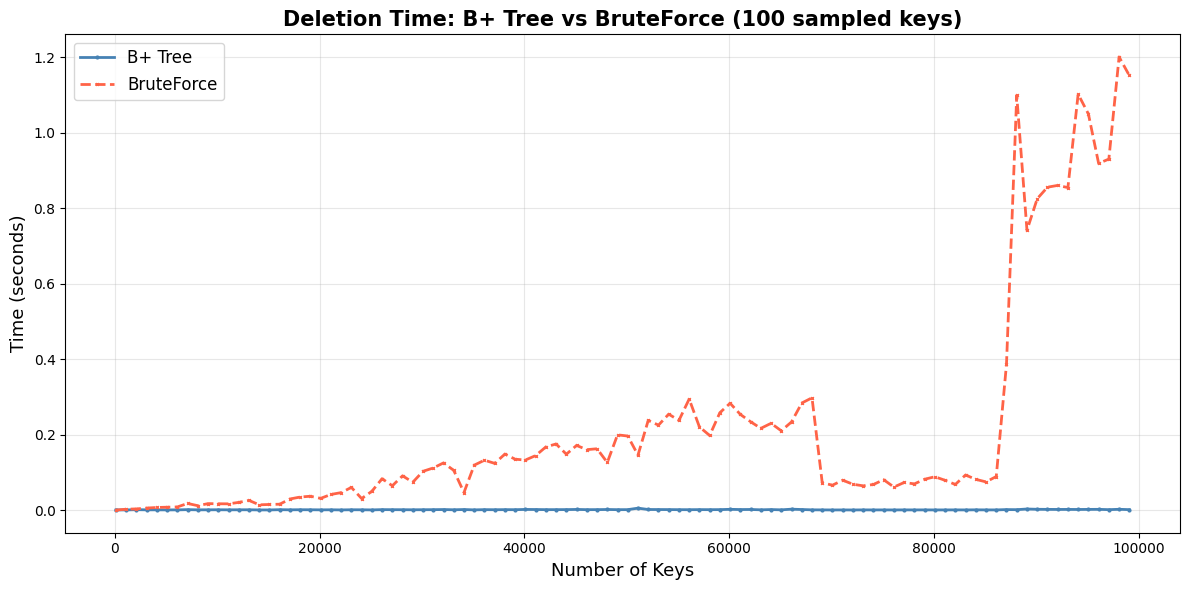

  Saved → graphs/deletion_benchmark.png


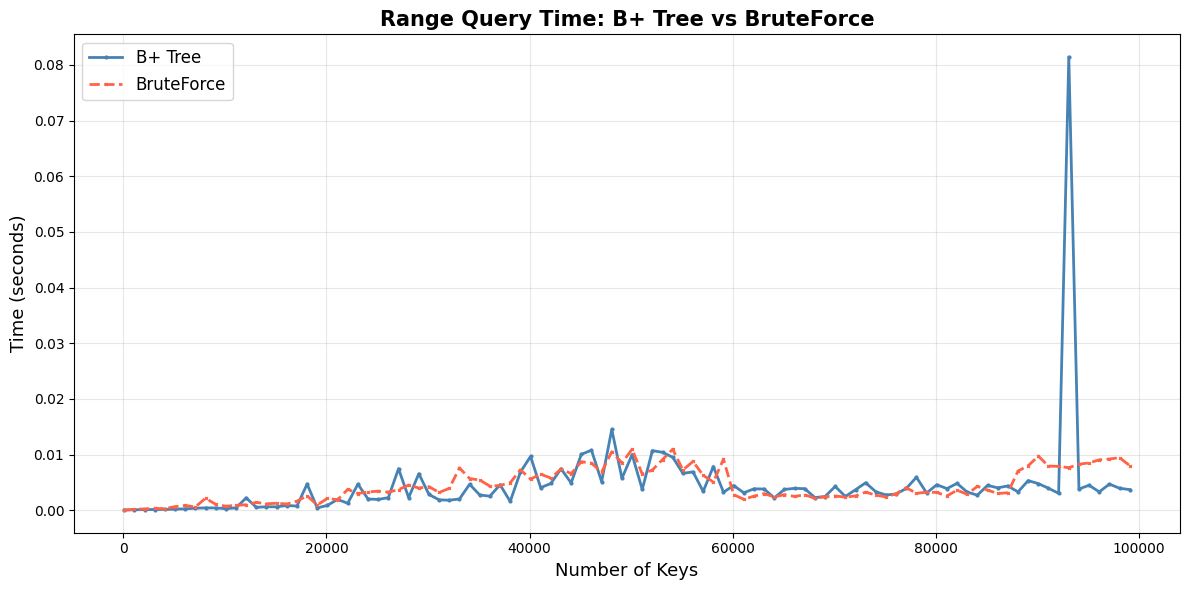

  Saved → graphs/range_benchmark.png


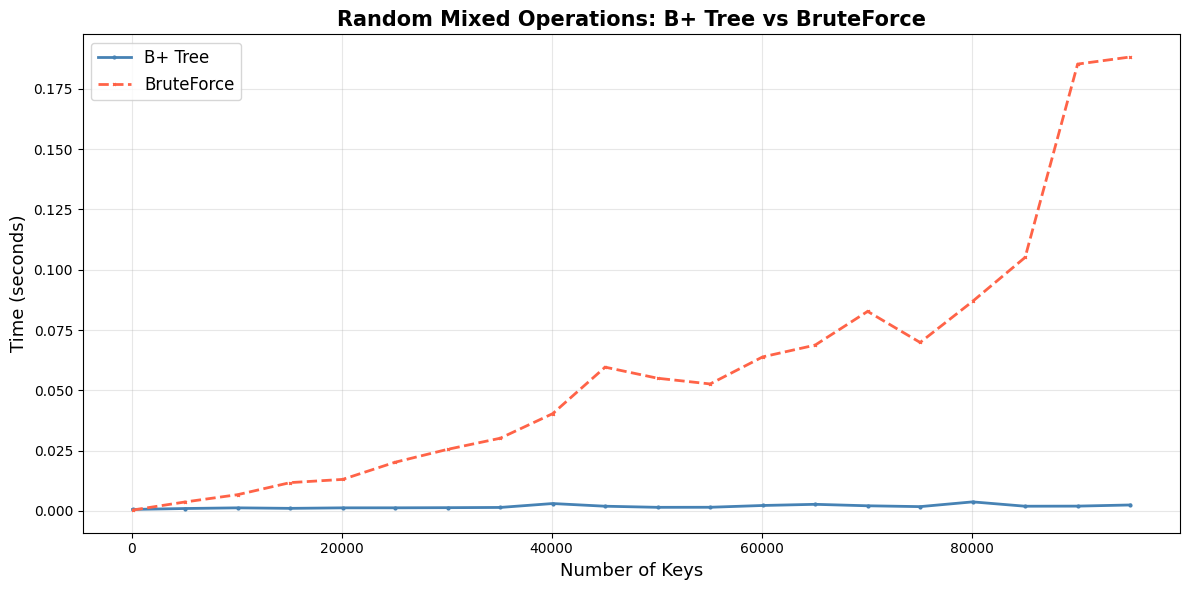

  Saved → graphs/random_benchmark.png


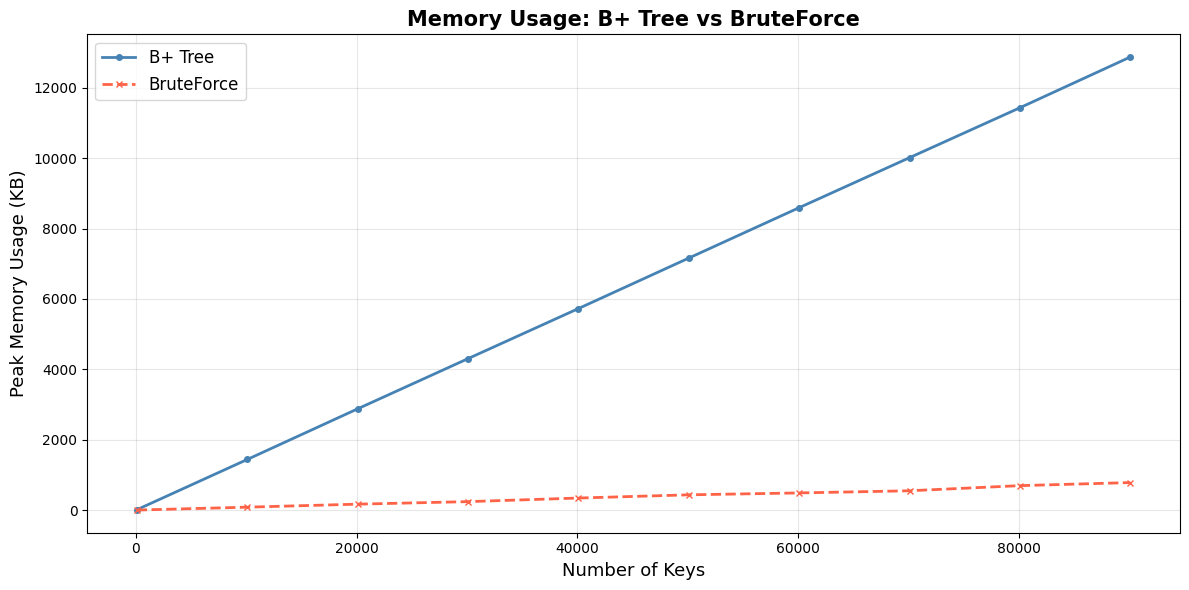

  Saved → graphs/memory_benchmark.png


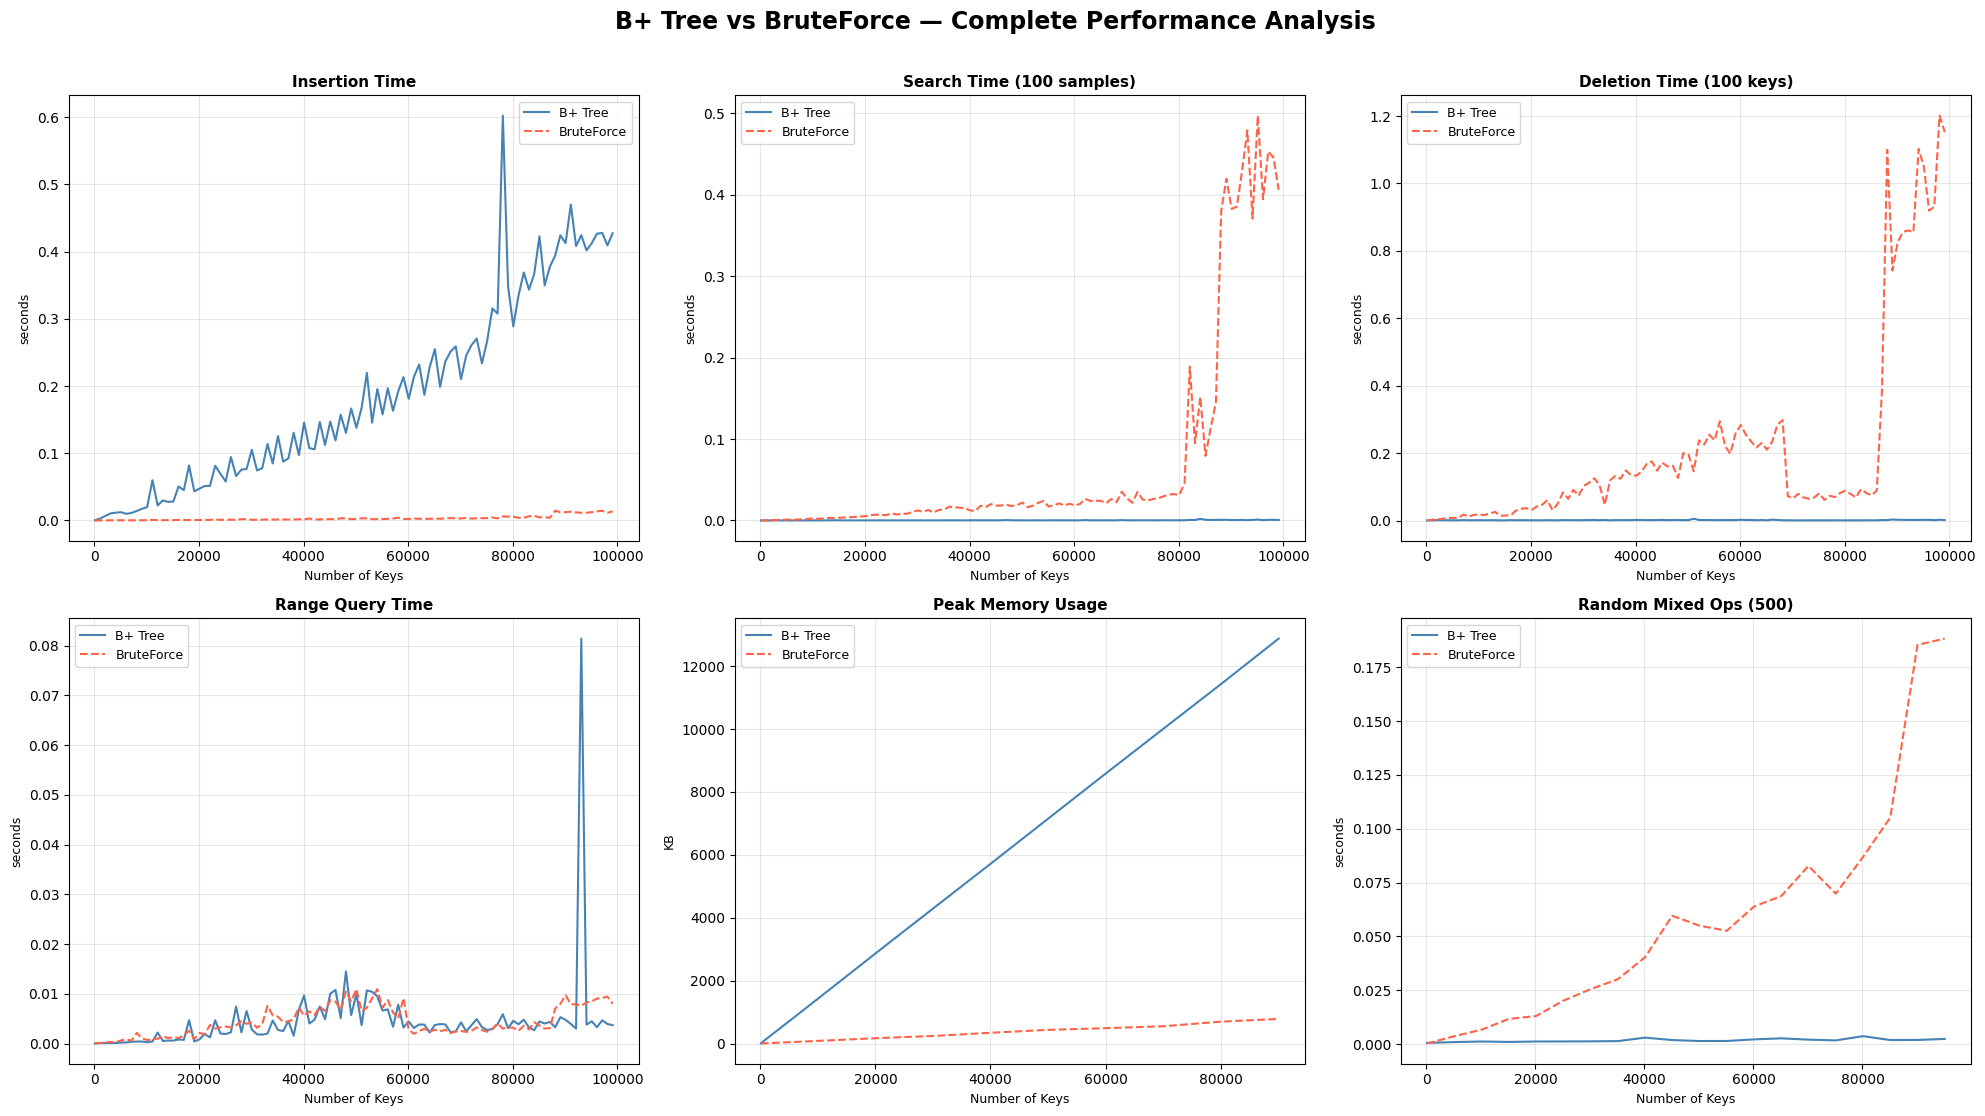

  Saved → graphs/full_benchmark_dashboard.png

All graphs saved to  graphs/  folder.
Benchmark complete!


In [2]:
# This single cell runs ALL 6 benchmarks and saves ALL graphs.

analyzer = PerformanceAnalyzer(order=4, seed=42)
analyzer.run_all(sizes=list(range(100, 100_000, 1_000)))

In [3]:
df = analyzer.summary_table()
display(df)

,Dataset Size,BPT Insert (s),BF Insert (s),BPT Search (s),BF Search (s),BPT Delete (s),BF Delete (s),BPT Range (s),BF Range (s)
0,100,0.000480,0.000030,0.000050,0.000020,0.000510,0.000150,0.000022,0.000016
1,50100,0.137880,0.002320,0.000220,0.021950,0.001290,0.196430,0.009972,0.010947
2,99100,0.427200,0.013490,0.000650,0.406050,0.001280,1.152300,0.003694,0.008004



  graphs/insertion_benchmark.png


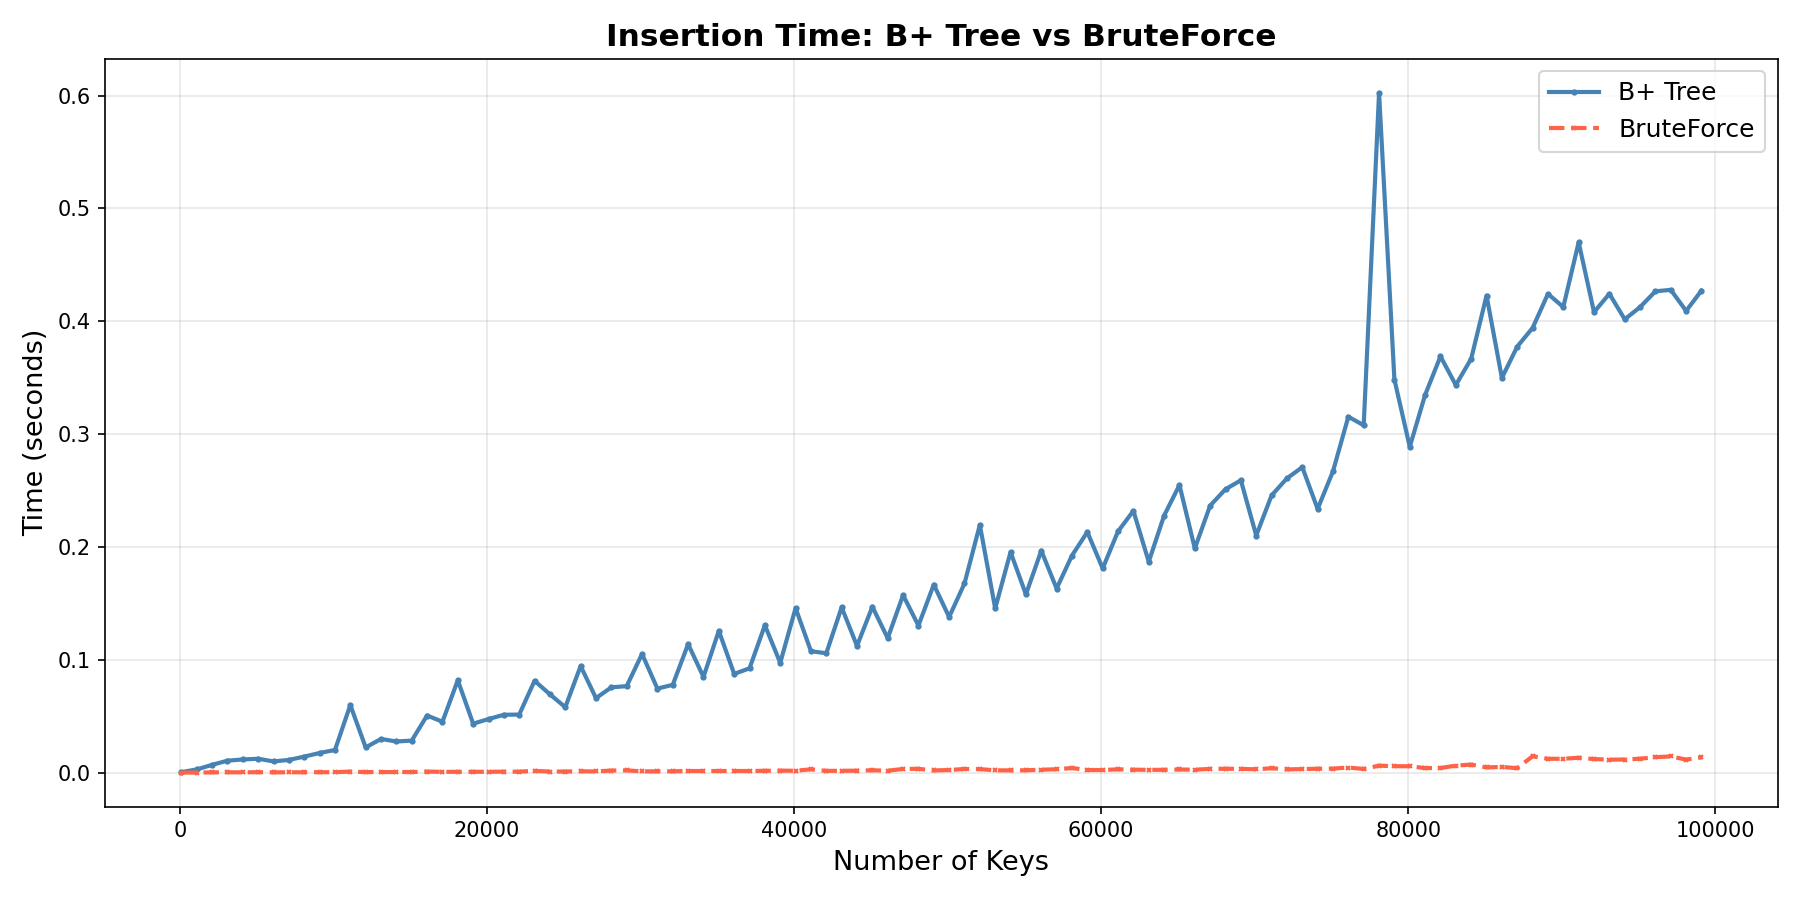


  graphs/search_benchmark.png


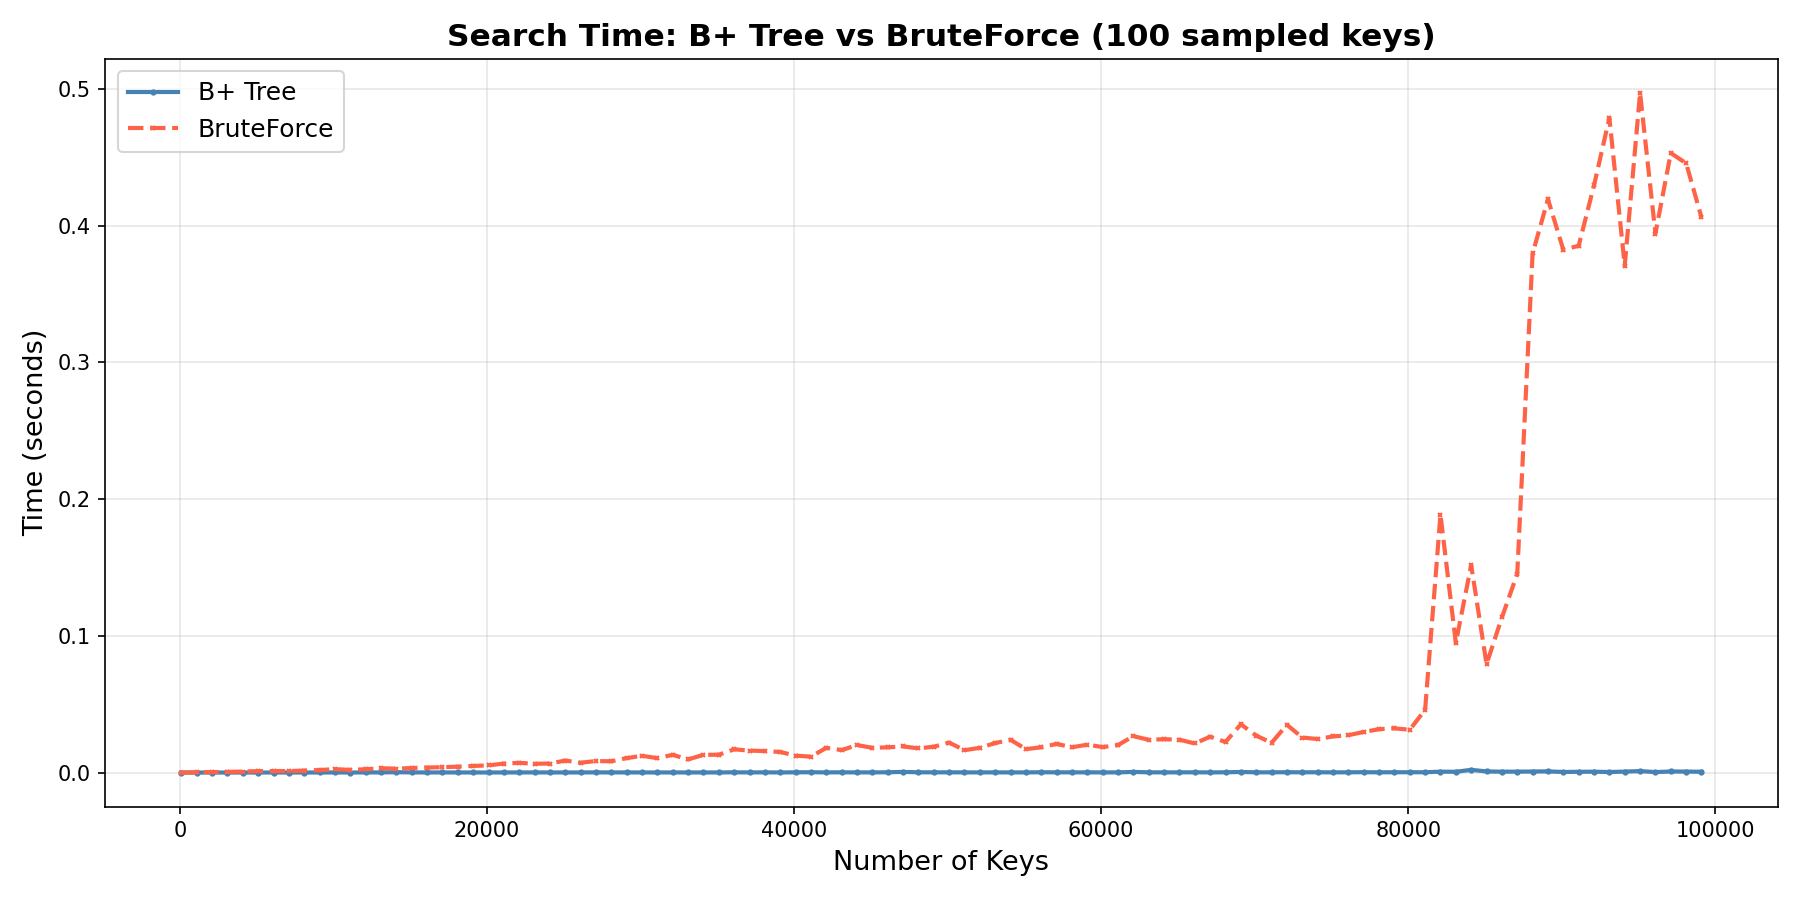


  graphs/deletion_benchmark.png


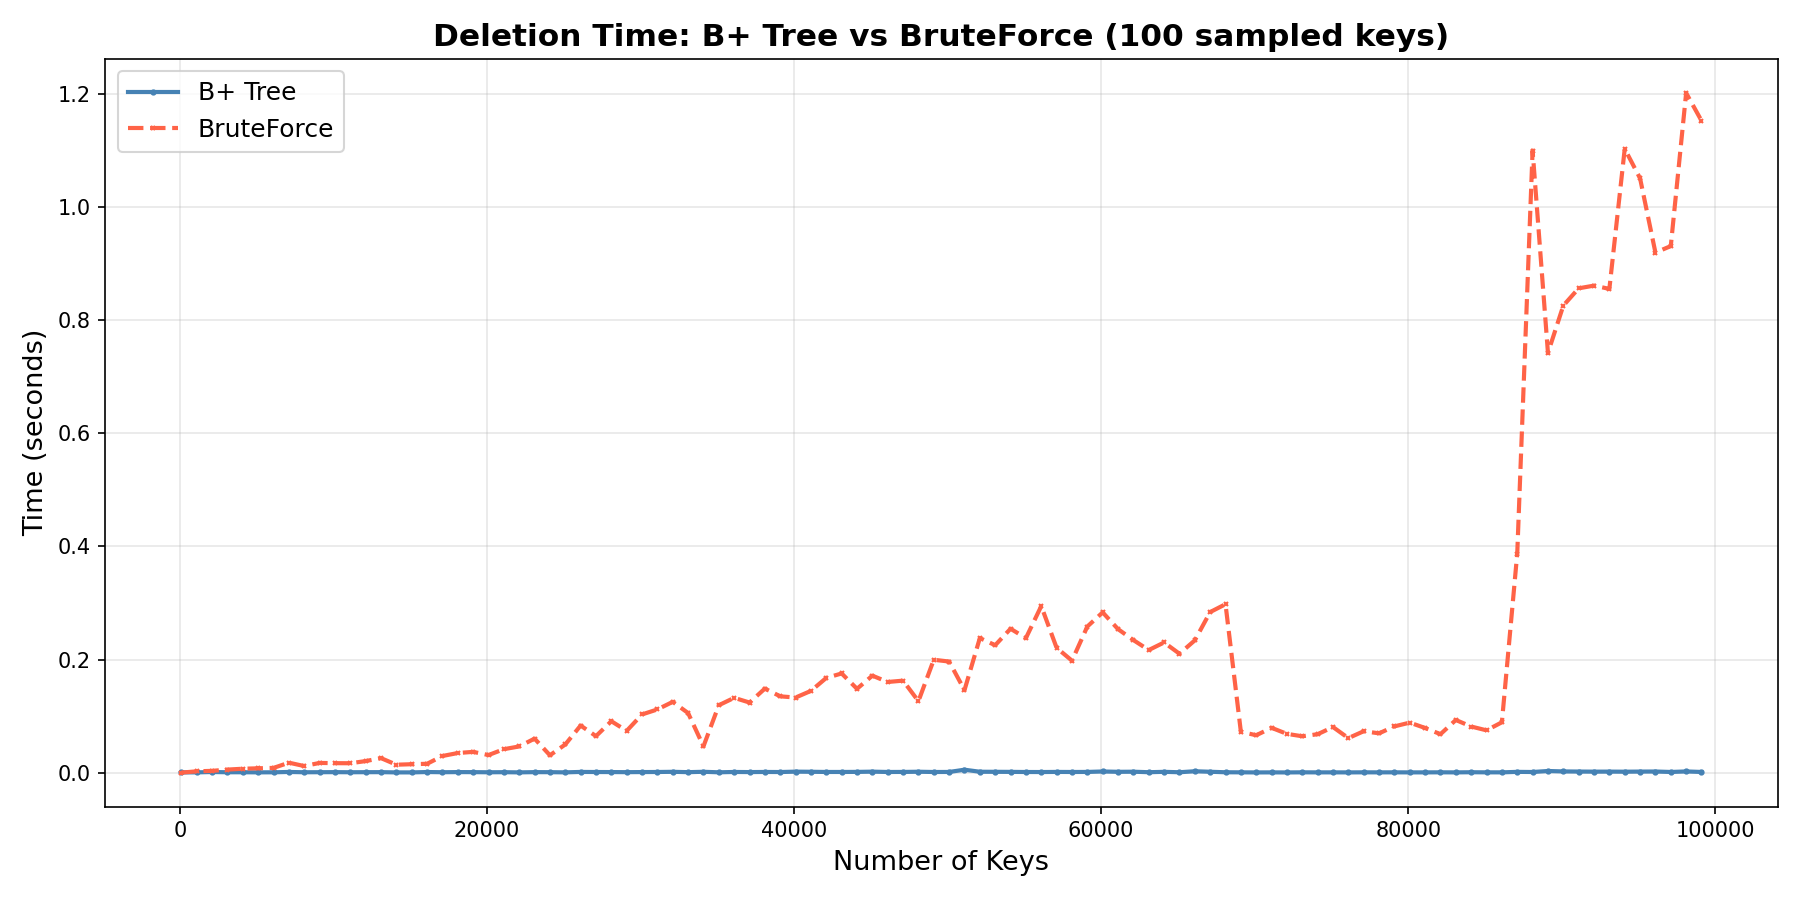


  graphs/range_benchmark.png


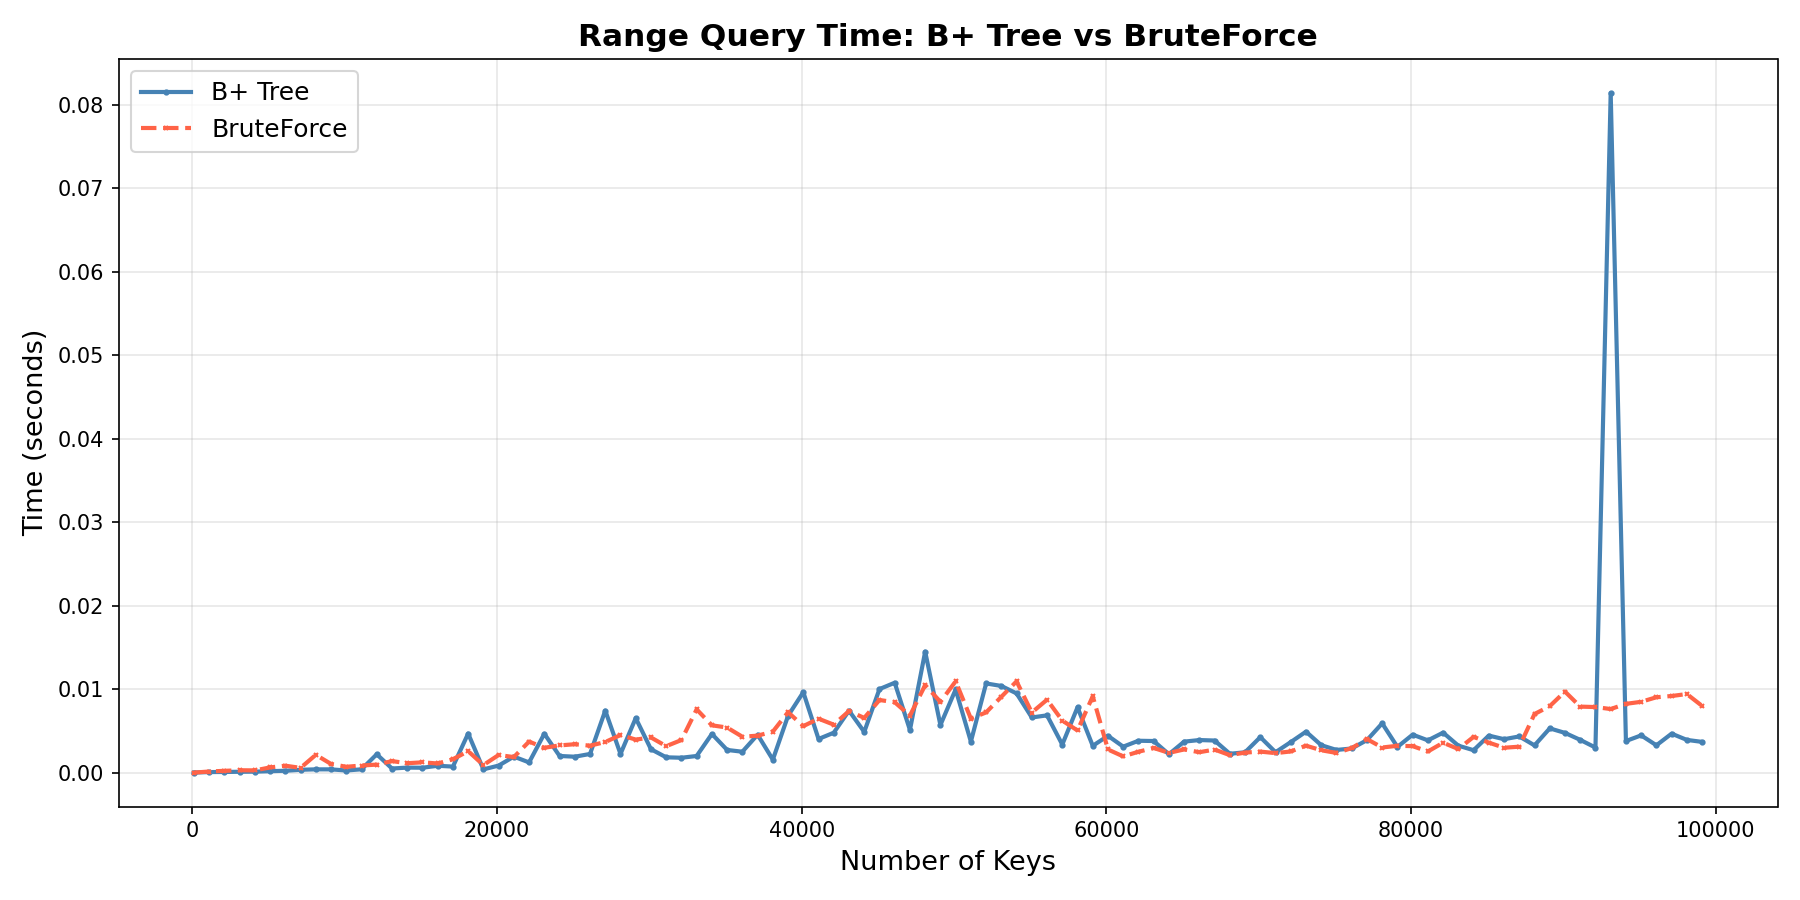


  graphs/memory_benchmark.png


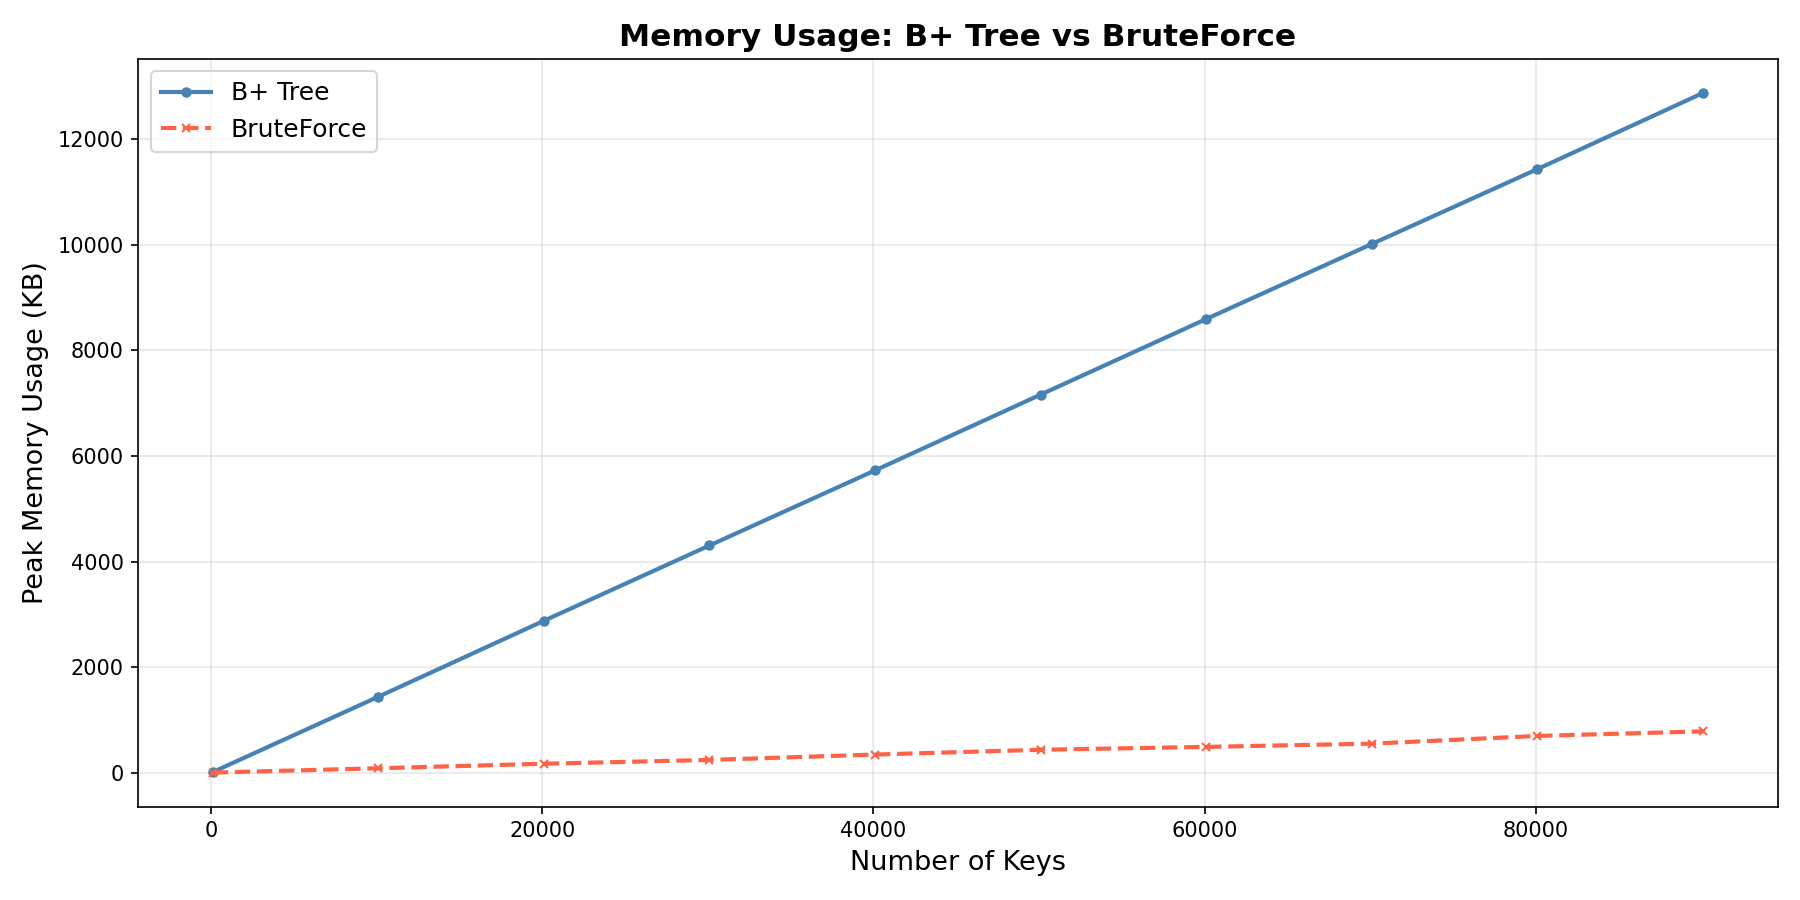


  graphs/random_benchmark.png


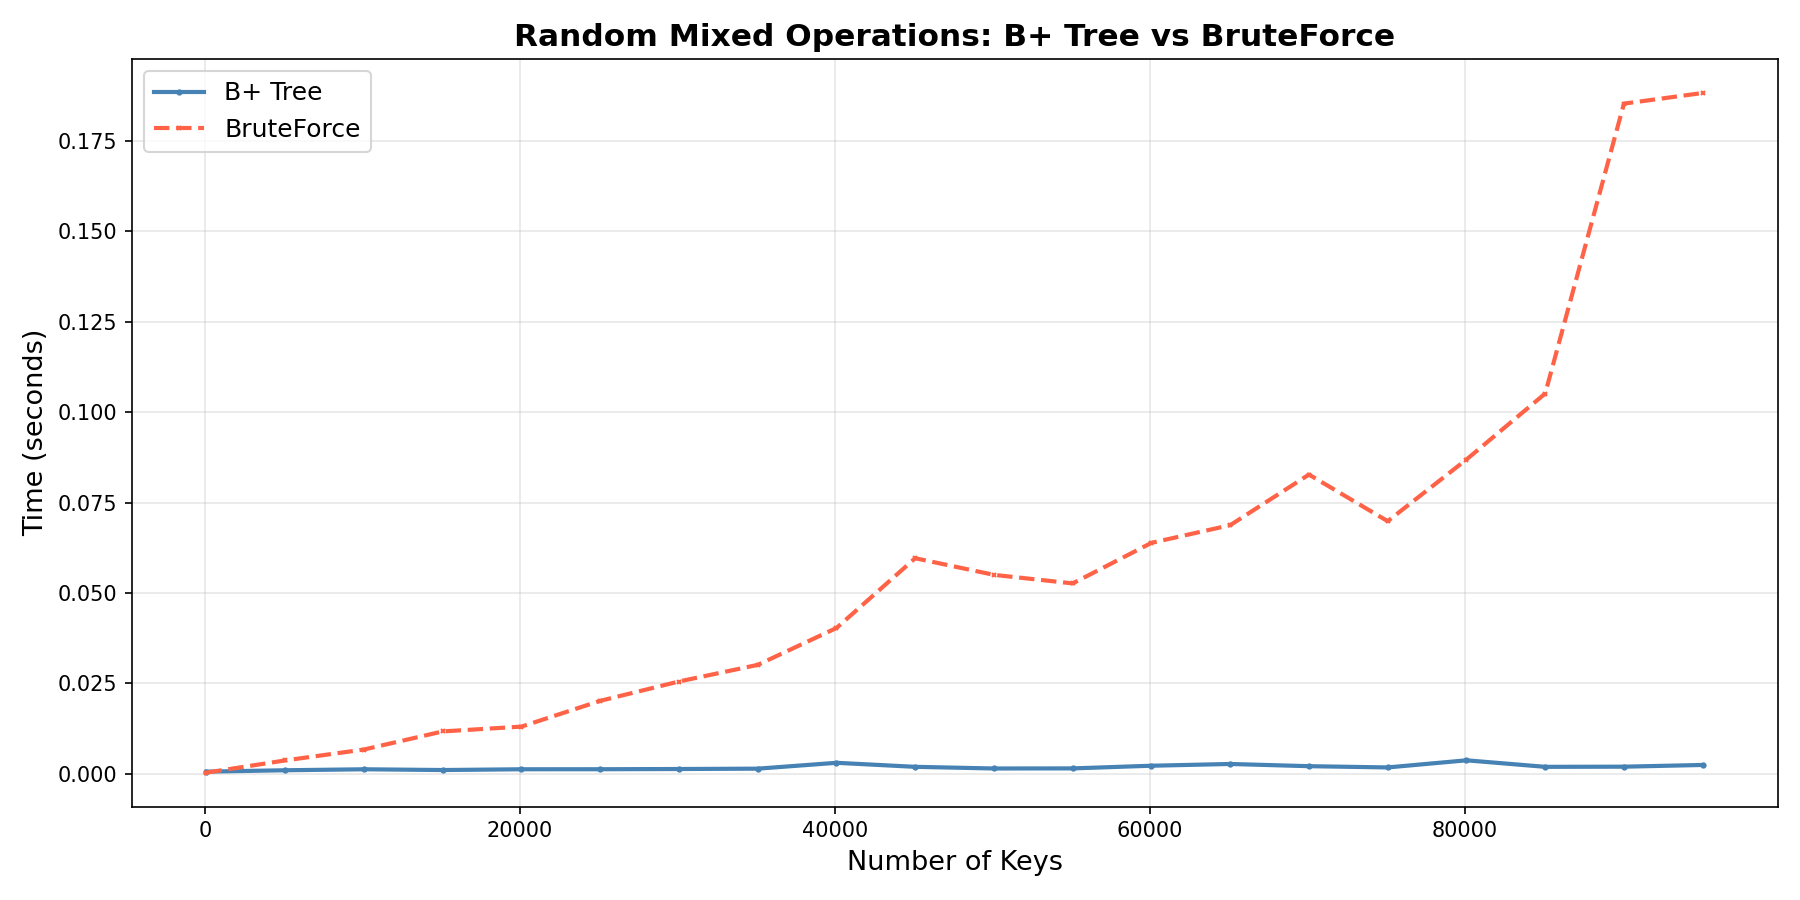

In [4]:
# Re-display any individual graph from the saved file
from IPython.display import Image, display as ipy_display

graphs = [
    'graphs/insertion_benchmark.png',
    'graphs/search_benchmark.png',
    'graphs/deletion_benchmark.png',
    'graphs/range_benchmark.png',
    'graphs/memory_benchmark.png',
    'graphs/random_benchmark.png',
]

for path in graphs:
    print(f"\n{'='*50}")
    print(f"  {path}")
    print('='*50)
    ipy_display(Image(filename=path, width=800))

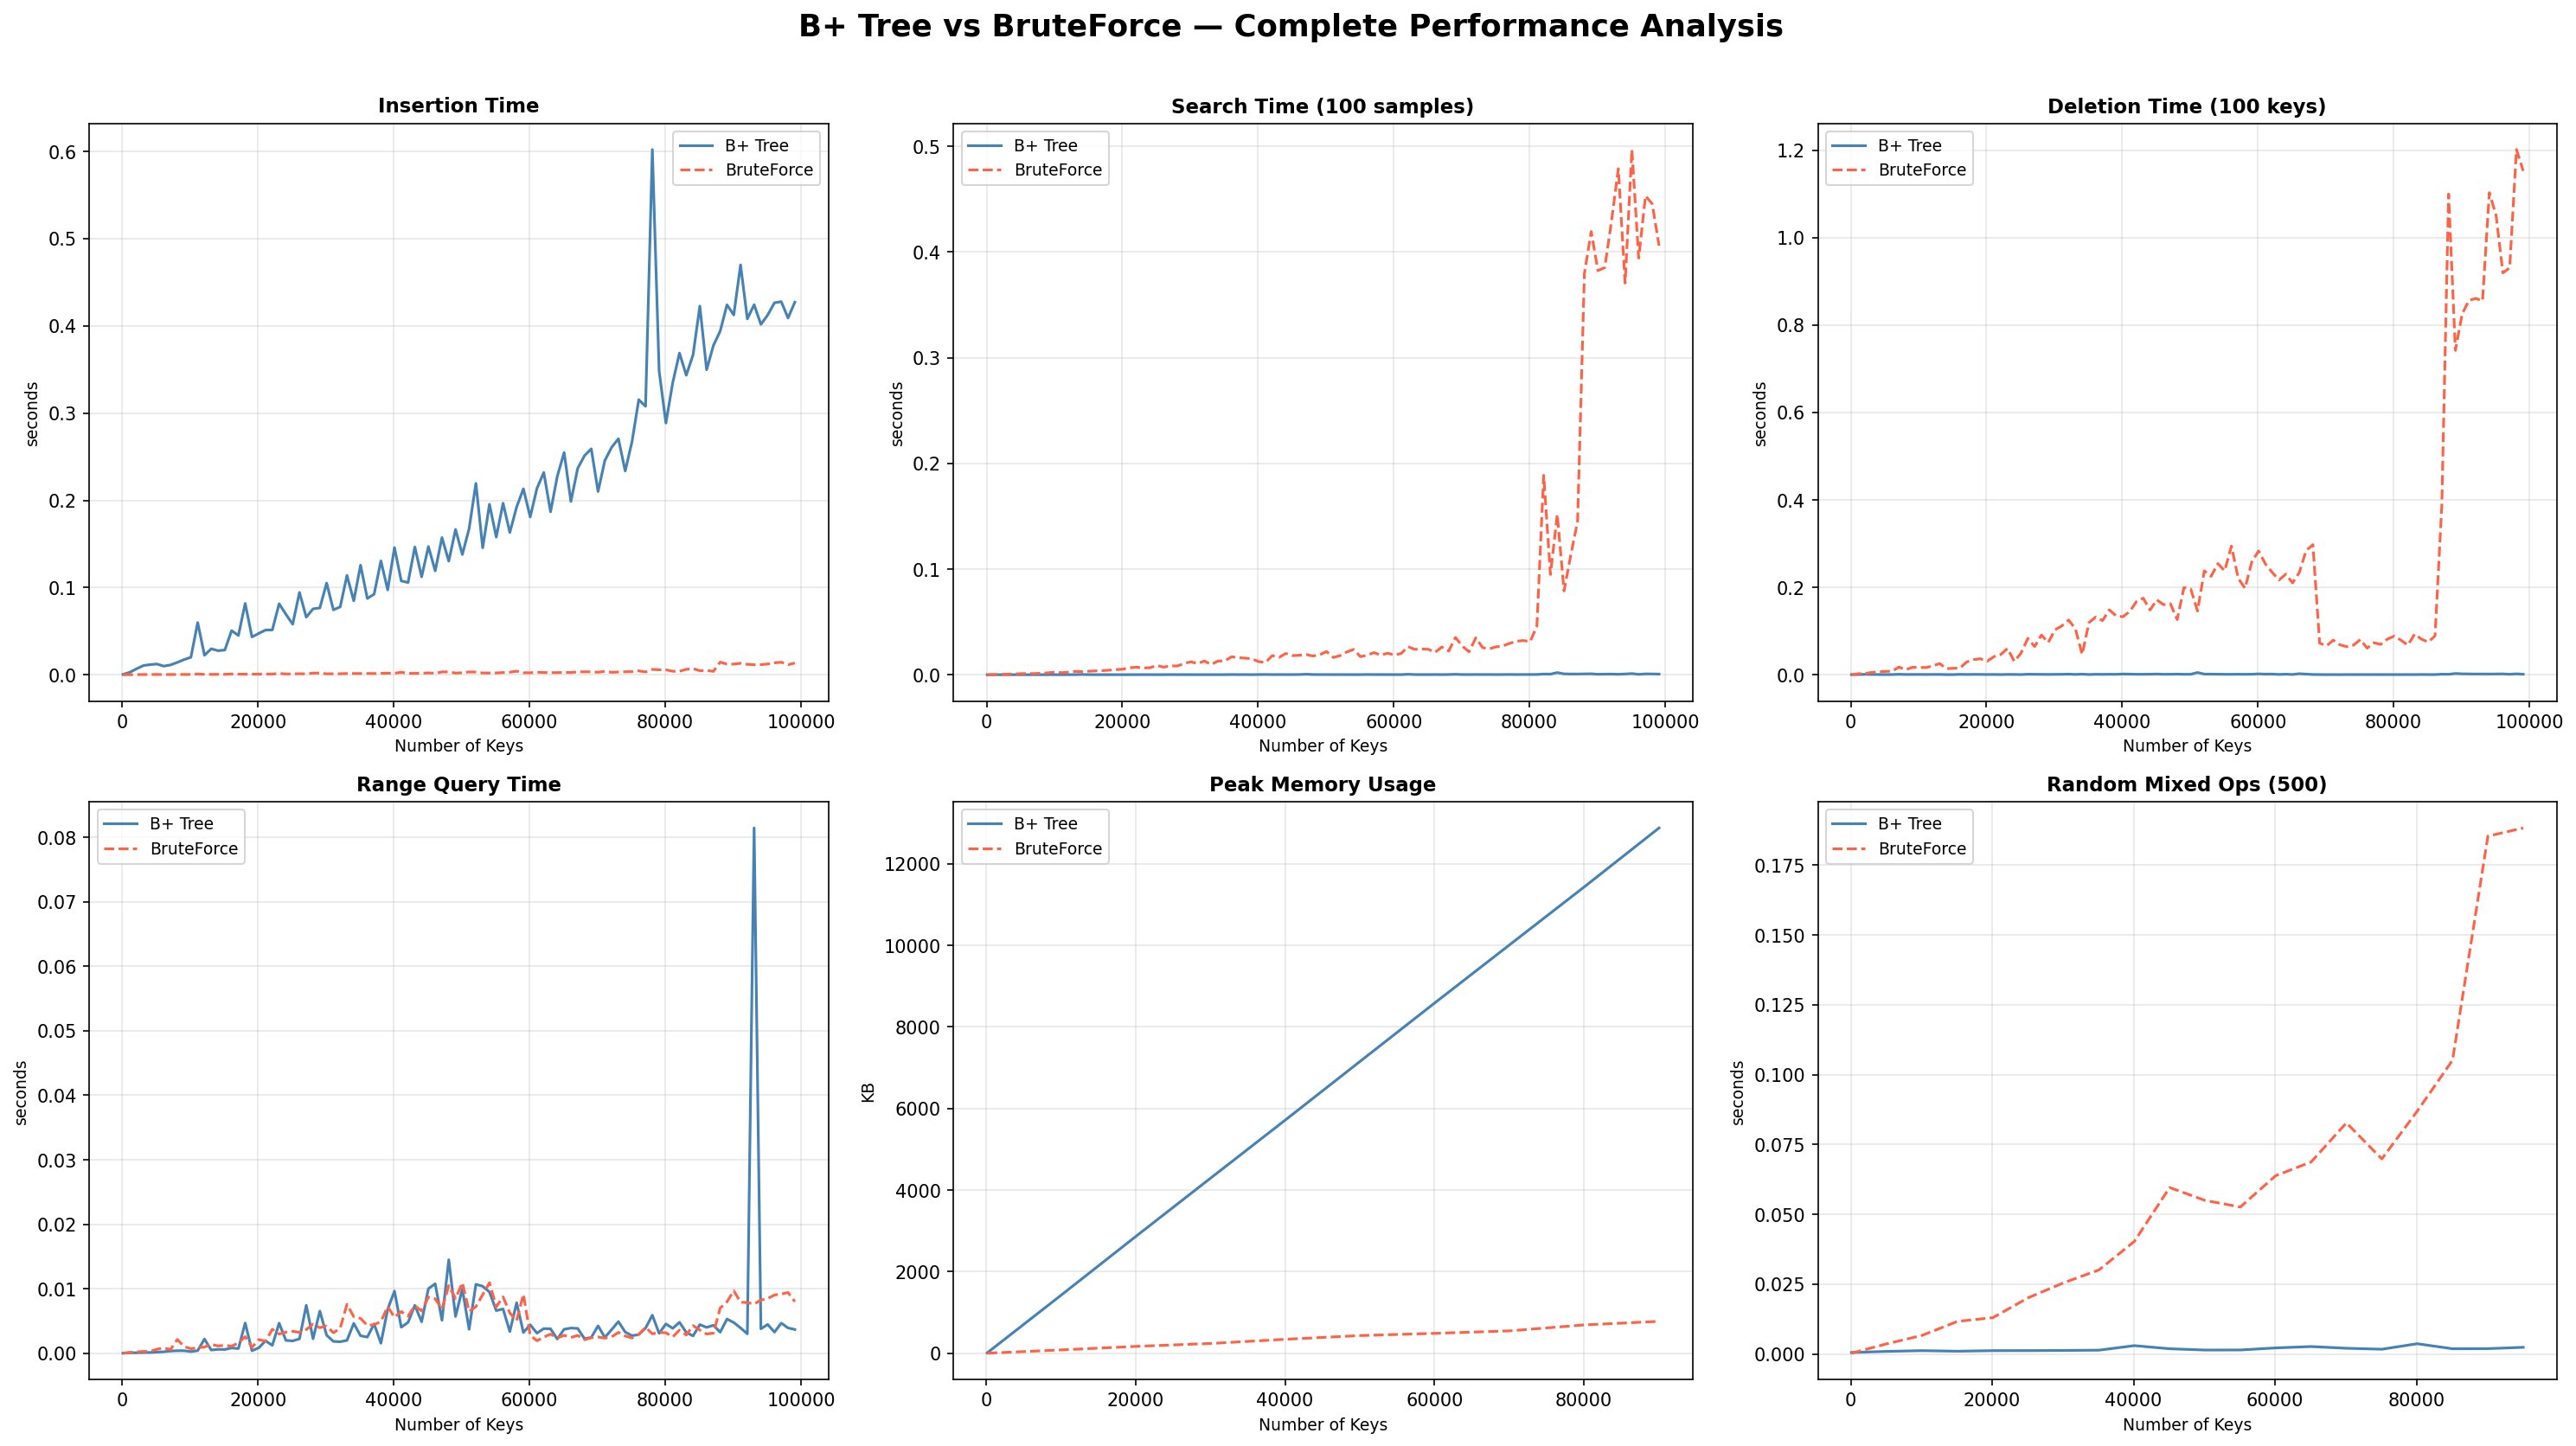

In [5]:
from IPython.display import Image, display as ipy_display
ipy_display(Image(filename='graphs/full_benchmark_dashboard.png', width=1000))

In [6]:
print("Keys stored in analyzer.results:")
for metric, data in analyzer.results.items():
    print(f"  {metric:<15} → {len(data['sizes'])} data points  |  "
          f"sizes: {data['sizes'][0]} → {data['sizes'][-1]}")

Keys stored in analyzer.results:
  insertion       → 100 data points  |  sizes: 100 → 99100
  search          → 100 data points  |  sizes: 100 → 99100
  deletion        → 100 data points  |  sizes: 100 → 99100
  range_query     → 100 data points  |  sizes: 100 → 99100
  random          → 20 data points  |  sizes: 100 → 95100
  memory          → 10 data points  |  sizes: 100 → 90100


---
## SubTask 3 — B+ Tree Visualisation using Graphviz

This section visualises the B+ Tree structure at different stages:
- **Stage 1**: Small tree — structure is clear, no splits yet
- **Stage 2**: After more inserts — node splits visible
- **Stage 3**: After deletions — node merges visible
- **Stage 4**: Large tree — full hierarchy with leaf linkage

Color coding:
- 🟡 **Yellow nodes** = Internal nodes (keys only, no data)
- 🔵 **Blue nodes** = Leaf nodes (actual records stored here)
- **Solid arrows** = Parent → child relationships
- **Dashed arrows** = Leaf → next leaf (linked list for range queries)

In [13]:
# Cell 2 — make sure this runs before anything else
import sys
import os

sys.path.insert(0, os.path.abspath('.'))


from database.bplustree import BPlusTree
from IPython.display import Image, display as ipy_display  # ← this line

os.makedirs('visualizations', exist_ok=True)
print("Setup ready.")

Setup ready.


In [14]:
def show_tree(bpt, filename, title=""):
    """
    Renders the B+ Tree using Graphviz and displays it inline.
    The new visualize_tree() handles saving automatically.
    """
    if title:
        print(f"\n{'='*55}")
        print(f"  {title}")
        print(f"{'='*55}")

    all_records = bpt.get_all()
    print(f"  Keys in tree : {[k for k, _ in all_records]}")
    print(f"  Total records: {len(all_records)}")
    print()

    # visualize_tree now saves directly to visualizations/<filename>.png
    dot = bpt.visualize_tree(filename=filename, save=True)

    if dot is None:
        print("Graphviz not available.")
        return

    dst = f'visualizations/{filename}.png'
    if os.path.exists(dst):
        ipy_display(Image(filename=dst, width=850))
    else:
        print(f"File not found: {dst}")

STAGE 1A — Empty tree (order=3)

  Stage 1A: Empty Tree
  Keys in tree : []
  Total records: 0

Tree saved → visualizations/01_empty_tree.png


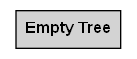

STAGE 1B — Inserting 3 keys (no splits yet, order=3)
  Inserted key: 10
  Inserted key: 20
  Inserted key: 5

  Stage 1B: 3 Keys — No Split Yet
  Keys in tree : [5, 10, 20]
  Total records: 3

Tree saved → visualizations/02_three_keys.png


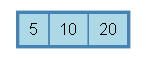

In [16]:
# ── STAGE 1A : Brand new empty tree ──────────────────────────
print("STAGE 1A — Empty tree (order=3)")
bpt = BPlusTree(order=3)
show_tree(bpt, '01_empty_tree', 'Stage 1A: Empty Tree')
# ── STAGE 1B : Insert 3 keys — no split yet ──────────────────
print("STAGE 1B — Inserting 3 keys (no splits yet, order=3)")
for key in [10, 20, 5]:
    bpt.insert(key, f"record_{key}")
    print(f"  Inserted key: {key}")

show_tree(bpt, '02_three_keys', 'Stage 1B: 3 Keys — No Split Yet')

In [15]:
import importlib
import database.bplustree as bpt_module
importlib.reload(bpt_module)
from database.bplustree import BPlusTree
print("Reloaded successfully.")

Reloaded successfully.


STAGE 2A — Inserting more keys to trigger first split
  Inserted key: 15
  Inserted key: 30

  Stage 2A: First Node Split
  Keys in tree : [5, 10, 15, 20, 30]
  Total records: 5

Tree saved → visualizations/03_first_split.png


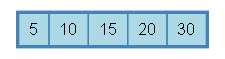

STAGE 2B — More inserts causing multiple splits
  Inserted key: 25
  Inserted key: 35
  Inserted key: 40
  Inserted key: 45
  Inserted key: 50

  Stage 2B: Multiple Splits — Tree Grows Taller
  Keys in tree : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
  Total records: 10

Tree saved → visualizations/04_multiple_splits.png


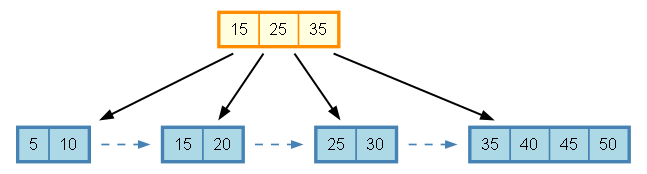

STAGE 2C — Inserting more keys to cause root split
  Inserted key: 55
  Inserted key: 60
  Inserted key: 65
  Inserted key: 70

  Stage 2C: Root Split — New Level Created
  Keys in tree : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
  Total records: 14

Tree saved → visualizations/05_root_split.png


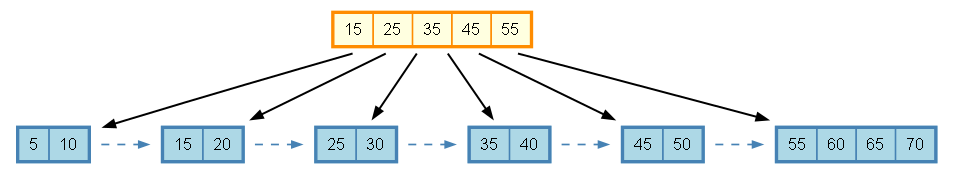

In [17]:
# ── STAGE 2A : Insert enough to trigger first split ──────────
# order=3 means max keys per node = 2*3-1 = 5
# Split happens when a node exceeds 5 keys

print("STAGE 2A — Inserting more keys to trigger first split")
for key in [15, 30]:
    bpt.insert(key, f"record_{key}")
    print(f"  Inserted key: {key}")

show_tree(bpt, '03_first_split', 'Stage 2A: First Node Split')

# ── STAGE 2B : More inserts — more splits, tree grows taller ─
print("STAGE 2B — More inserts causing multiple splits")
for key in [25, 35, 40, 45, 50]:
    bpt.insert(key, f"record_{key}")
    print(f"  Inserted key: {key}")

show_tree(bpt, '04_multiple_splits', 'Stage 2B: Multiple Splits — Tree Grows Taller')

# ── STAGE 2C : Root split — tree gains a new level ───────────
print("STAGE 2C — Inserting more keys to cause root split")
for key in [55, 60, 65, 70]:
    bpt.insert(key, f"record_{key}")
    print(f"  Inserted key: {key}")

show_tree(bpt, '05_root_split', 'Stage 2C: Root Split — New Level Created')

STAGE 3A — Deleting key 45 (simple removal)
  Delete 45 → success: True

  Stage 3A: Simple Deletion (No Underflow)
  Keys in tree : [5, 10, 15, 20, 25, 30, 35, 40, 50, 55, 60, 65, 70]
  Total records: 13

Tree saved → visualizations/06_simple_delete.png


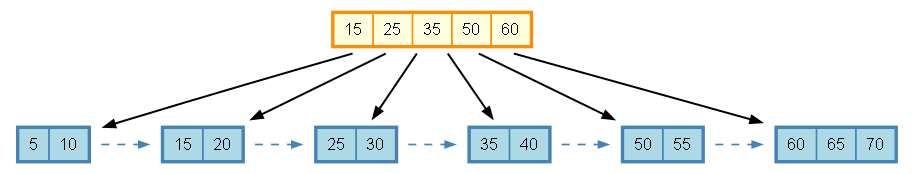

STAGE 3B — Deleting keys that trigger borrowing from sibling
  Delete 35 → success: True
  Delete 40 → success: True

  Stage 3B: Deletion with Borrowing from Sibling
  Keys in tree : [5, 10, 15, 20, 25, 30, 50, 55, 60, 65, 70]
  Total records: 11

Tree saved → visualizations/07_borrow.png


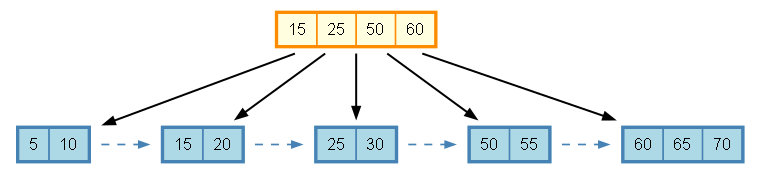

STAGE 3C — Deleting keys that trigger node merge
  Delete 55 → success: True
  Delete 60 → success: True

  Stage 3C: Deletion with Node Merge
  Keys in tree : [5, 10, 15, 20, 25, 30, 50, 65, 70]
  Total records: 9

Tree saved → visualizations/08_merge.png


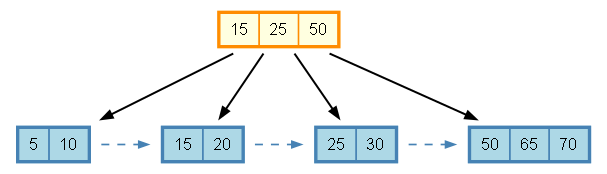

In [18]:
# ── STAGE 3A : Delete a key — simple removal, no underflow ───
print("STAGE 3A — Deleting key 45 (simple removal)")
result = bpt.delete(45)
print(f"  Delete 45 → success: {result}")

show_tree(bpt, '06_simple_delete', 'Stage 3A: Simple Deletion (No Underflow)')
# ── STAGE 3B : Delete keys that cause borrowing ──────────────
print("STAGE 3B — Deleting keys that trigger borrowing from sibling")
for key in [35, 40]:
    result = bpt.delete(key)
    print(f"  Delete {key} → success: {result}")

show_tree(bpt, '07_borrow', 'Stage 3B: Deletion with Borrowing from Sibling')
# ── STAGE 3C : Delete keys that cause node merge ─────────────
print("STAGE 3C — Deleting keys that trigger node merge")
for key in [55, 60]:
    result = bpt.delete(key)
    print(f"  Delete {key} → success: {result}")

show_tree(bpt, '08_merge', 'Stage 3C: Deletion with Node Merge')

STAGE 4 — Large tree: 30 random keys, order=4
(Demonstrates full hierarchy + long leaf chain)

Inserted 30 keys.

  Stage 4: Large Tree (30 keys, order=4)
  Keys in tree : [4, 13, 14, 16, 17, 45, 48, 53, 58, 72, 80, 82, 102, 111, 112, 113, 115, 120, 126, 141, 143, 173, 175, 195, 215, 217, 230, 259, 280, 288]
  Total records: 30

Tree saved → visualizations/09_large_tree.png


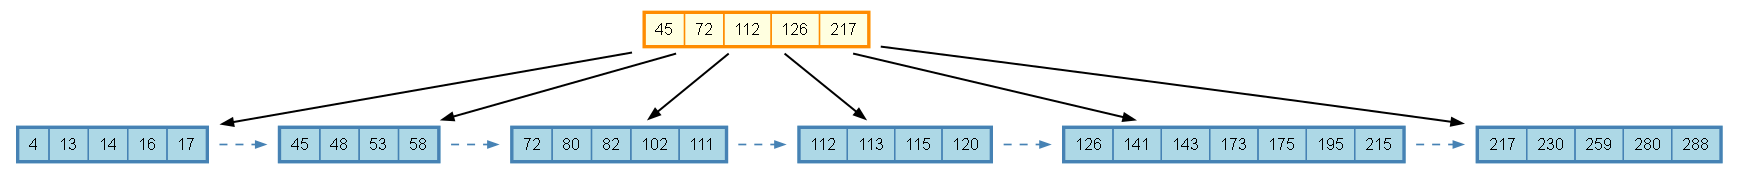

In [19]:
# ── STAGE 4 : Large tree with order=4 ────────────────────────
# This shows a realistic tree with many levels and leaf linkage
import random
random.seed(42)

print("STAGE 4 — Large tree: 30 random keys, order=4")
print("(Demonstrates full hierarchy + long leaf chain)\n")

bpt_large = BPlusTree(order=4)
large_keys = random.sample(range(1, 300), 30)

for key in large_keys:
    bpt_large.insert(key, f"record_{key}")

print(f"Inserted {len(large_keys)} keys.")
show_tree(bpt_large, '09_large_tree', 'Stage 4: Large Tree (30 keys, order=4)')

In [20]:
# ── STAGE 5 : Confirm leaf linked list works correctly ────────
# The dashed arrows in the diagram represent this chain.
# We prove it works by running a range query.

print("STAGE 5 — Verifying leaf linked list via range query")
print()

all_keys_sorted = sorted(large_keys)
lo = all_keys_sorted[len(all_keys_sorted) // 4]       # 25th percentile
hi = all_keys_sorted[3 * len(all_keys_sorted) // 4]   # 75th percentile

print(f"Range query: keys between {lo} and {hi}")
print()

results = bpt_large.range_query(lo, hi)
print(f"Results ({len(results)} records found):")
for k, v in results:
    print(f"  key={k:4d}  →  {v}")

print()
print("These keys correspond to the leaf nodes connected")
print("by the dashed arrows in Stage 4's diagram above.")

STAGE 5 — Verifying leaf linked list via range query

Range query: keys between 53 and 175

Results (16 records found):
  key=  53  →  record_53
  key=  58  →  record_58
  key=  72  →  record_72
  key=  80  →  record_80
  key=  82  →  record_82
  key= 102  →  record_102
  key= 111  →  record_111
  key= 112  →  record_112
  key= 113  →  record_113
  key= 115  →  record_115
  key= 120  →  record_120
  key= 126  →  record_126
  key= 141  →  record_141
  key= 143  →  record_143
  key= 173  →  record_173
  key= 175  →  record_175

These keys correspond to the leaf nodes connected
by the dashed arrows in Stage 4's diagram above.


  VISUALISATION GALLERY — All Stages

  ► Stage 1: First 3 Keys


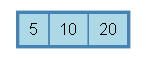


  ► Stage 2A: First Split


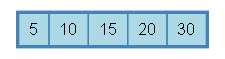


  ► Stage 2C: Root Split


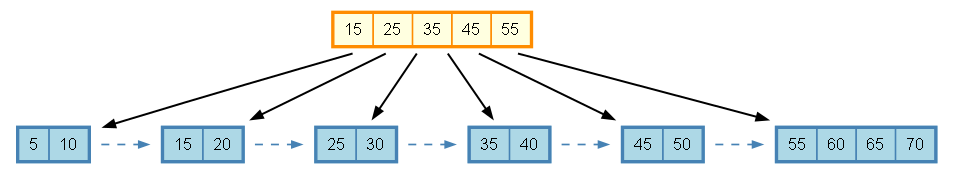


  ► Stage 3C: After Merges


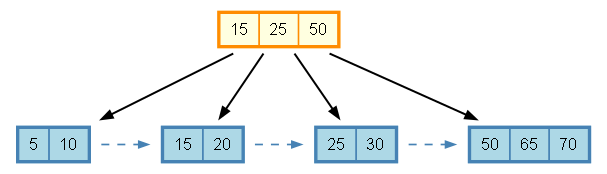


  ► Stage 4: Large Tree


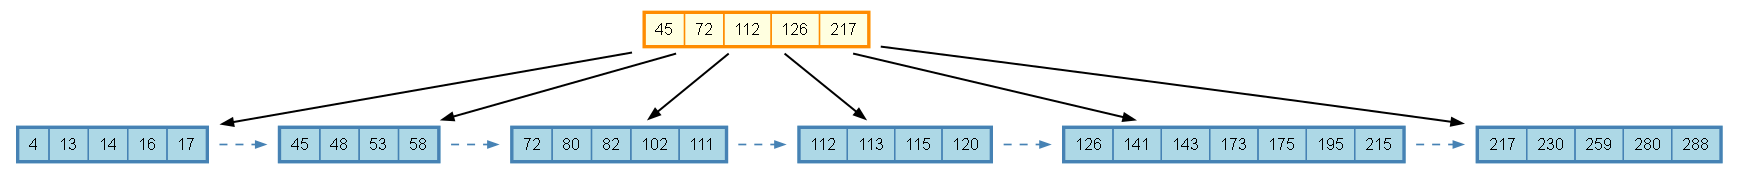

In [21]:
# ── GALLERY : Show all saved visualisations side by side ──────
from IPython.display import Image, display as ipy_display, HTML

stages = [
    ('visualizations/02_three_keys.png',      'Stage 1: First 3 Keys'),
    ('visualizations/03_first_split.png',     'Stage 2A: First Split'),
    ('visualizations/05_root_split.png',      'Stage 2C: Root Split'),
    ('visualizations/08_merge.png',           'Stage 3C: After Merges'),
    ('visualizations/09_large_tree.png',      'Stage 4: Large Tree'),
]

print("=" * 55)
print("  VISUALISATION GALLERY — All Stages")
print("=" * 55)

for path, label in stages:
    if os.path.exists(path):
        print(f"\n  ► {label}")
        ipy_display(Image(filename=path, width=850))
    else:
        print(f"  [MISSING] {path}")

## Visualisation Summary

### What Each Stage Shows

| Stage | Keys | What to Observe |
|-------|------|-----------------|
| 1B | 3 keys | Single leaf node — no splits yet |
| 2A | 5 keys | First split — root node created |
| 2C | 14 keys | Root split — tree gains a new level |
| 3C | 10 keys | Merge after deletion — tree shrinks |
| 4  | 30 keys | Full hierarchy — long leaf chain visible |

### Key Observations

**Leaf vs Internal Nodes**
Internal nodes (yellow) store only separator keys — no actual data.
Leaf nodes (blue) store the actual key-value records.

**Splitting Rule**
When a leaf splits, the middle key is *copied* to the parent —
it stays in the leaf too. When an internal node splits,
the middle key is *promoted* — it leaves the child.

**Leaf Linked List**
The dashed blue arrows connect every leaf node to its right
neighbor in sorted order. This enables range queries to skip
the tree entirely after reaching the start key — they just
follow the chain until the end key is passed.

**Tree Height**
The tree only grows taller when the root splits. All insertions
and deletions happen at the leaf level — internal nodes only
change to maintain balance.
```



---
## SubTask 4 — Performance Testing & Benchmarking

This section conducts a rigorous comparative analysis between
the B+ Tree and the BruteForce approach across 6 metrics:

1. **Insertion Time** — time to insert N keys
2. **Search Time** — time to search 100 sampled keys
3. **Deletion Time** — time to delete 100 sampled keys
4. **Range Query Time** — time to fetch keys in middle 10% range
5. **Random Mixed Operations** — realistic mixed workload
6. **Memory Usage** — peak RAM consumed during insertion

Dataset sizes: `range(100, 100000, 1000)` → 99 data points
B+ Tree order: 4 | Random seed: 42 (reproducible)

In [22]:
import sys
import os
import time
import tracemalloc
import random

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, os.path.abspath('.'))

from database.bplustree  import BPlusTree
from database.bruteforce import BruteForceDB
from database            import PerformanceAnalyzer

# Plot styling — applied globally
plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

os.makedirs('graphs', exist_ok=True)

print("All imports ready.")
print(f"Working directory: {os.getcwd()}")

All imports ready.
Working directory: d:\Module_A


In [23]:
# Dataset sizes exactly as specified in the assignment
SIZES = list(range(100, 100_000, 1_000))
ORDER = 4
SEED  = 42

random.seed(SEED)

print(f"Total dataset sizes : {len(SIZES)}")
print(f"Smallest size       : {SIZES[0]}")
print(f"Largest size        : {SIZES[-1]}")
print(f"B+ Tree order       : {ORDER}")
print(f"Random seed         : {SEED}")

Total dataset sizes : 100
Smallest size       : 100
Largest size        : 99100
B+ Tree order       : 4
Random seed         : 42



  PERFORMANCE BENCHMARKING
  B+ Tree  vs  BruteForce
  Sizes   : 100 → 99100 (100 points)
  BPT order: 4   |   Seed: 42

[ 1 / 6 ]  Running insertion benchmark ...
         25 / 100 sizes done ...
         50 / 100 sizes done ...
         75 / 100 sizes done ...
         100 / 100 sizes done ...
         Done.

[ 2 / 6 ]  Running search benchmark ...
         25 / 100 sizes done ...
         50 / 100 sizes done ...
         75 / 100 sizes done ...
         100 / 100 sizes done ...
         Done.

[ 3 / 6 ]  Running deletion benchmark ...
         25 / 100 sizes done ...
         50 / 100 sizes done ...
         75 / 100 sizes done ...
         100 / 100 sizes done ...
         Done.

[ 4 / 6 ]  Running range query benchmark ...
         25 / 100 sizes done ...
         50 / 100 sizes done ...
         75 / 100 sizes done ...
         100 / 100 sizes done ...
         Done.

[ 5 / 6 ]  Running random mixed operations benchmark ...
         5 / 20 sizes done ...
         10 / 20 sizes d

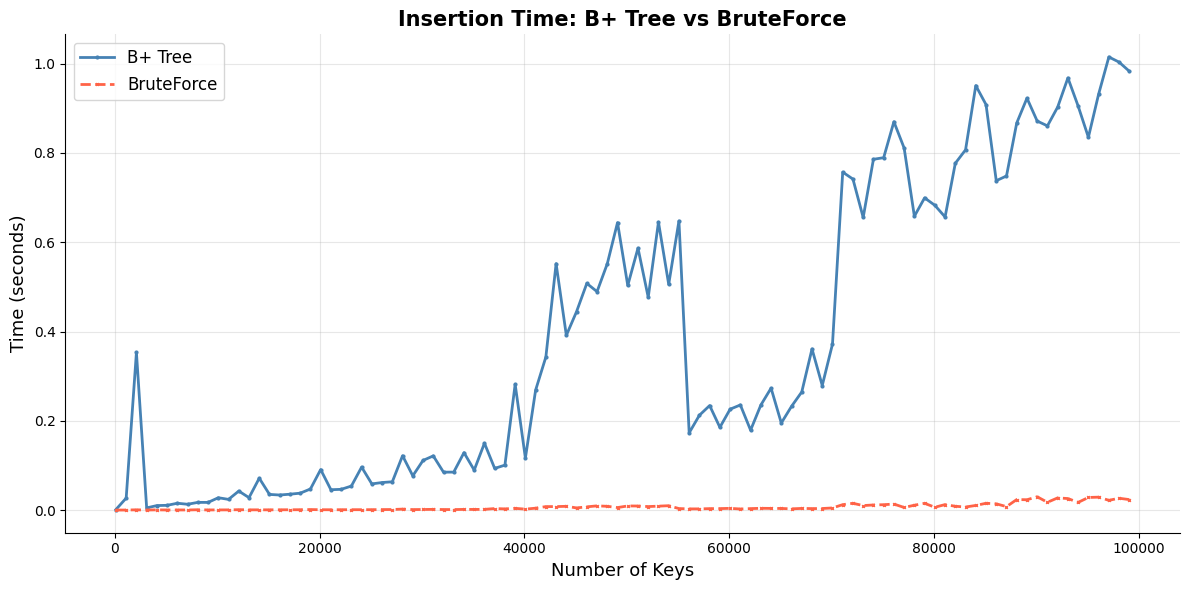

  Saved → graphs/insertion_benchmark.png


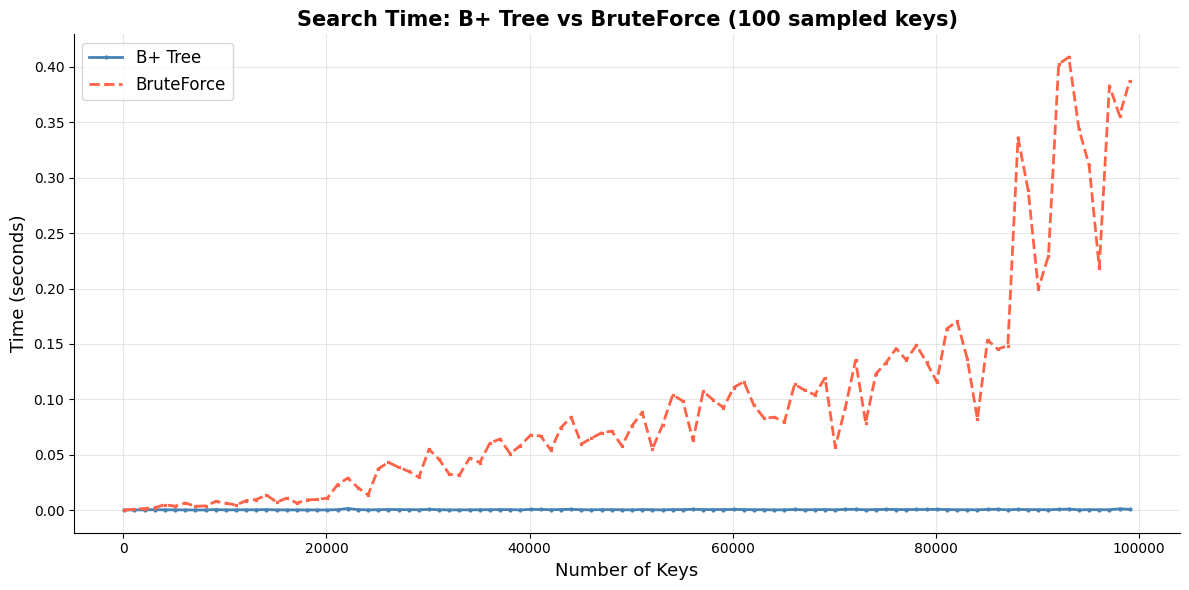

  Saved → graphs/search_benchmark.png


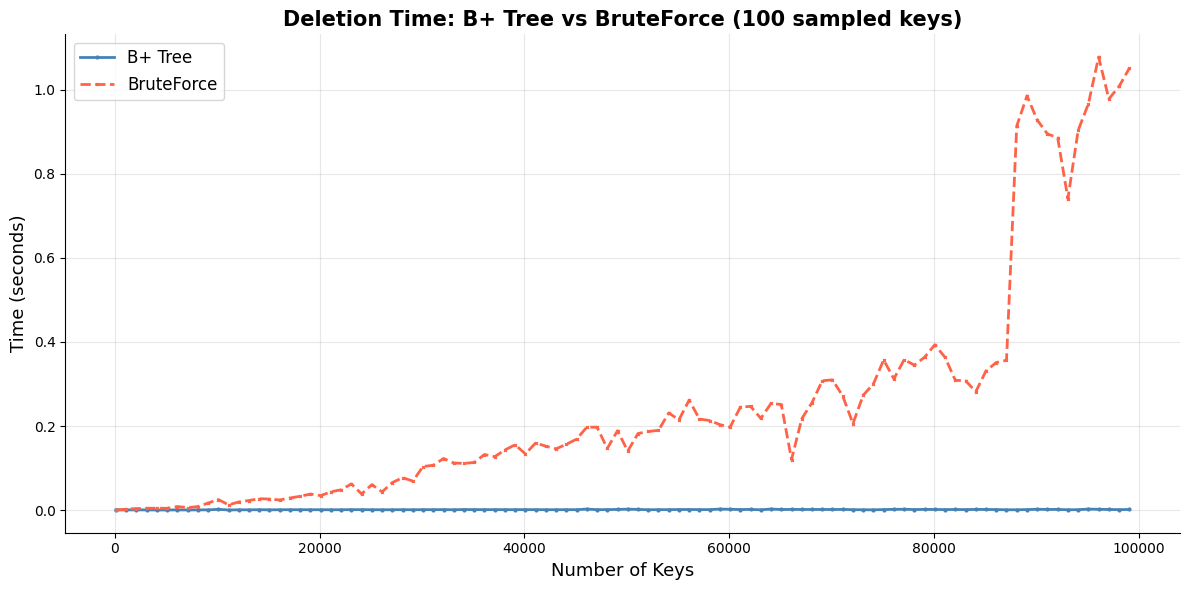

  Saved → graphs/deletion_benchmark.png


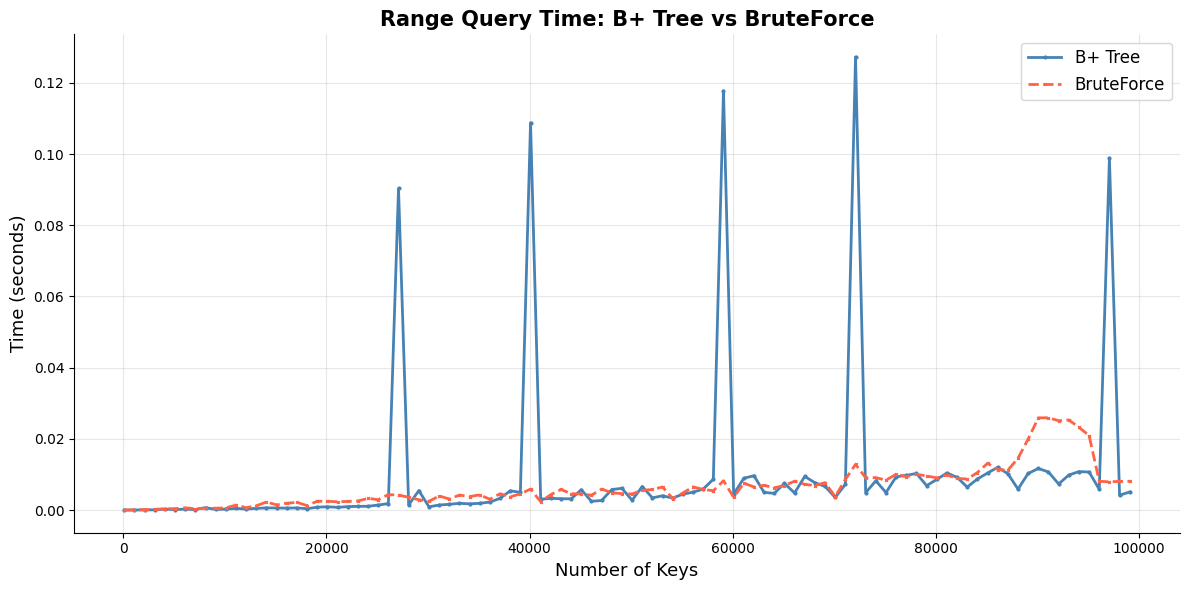

  Saved → graphs/range_benchmark.png


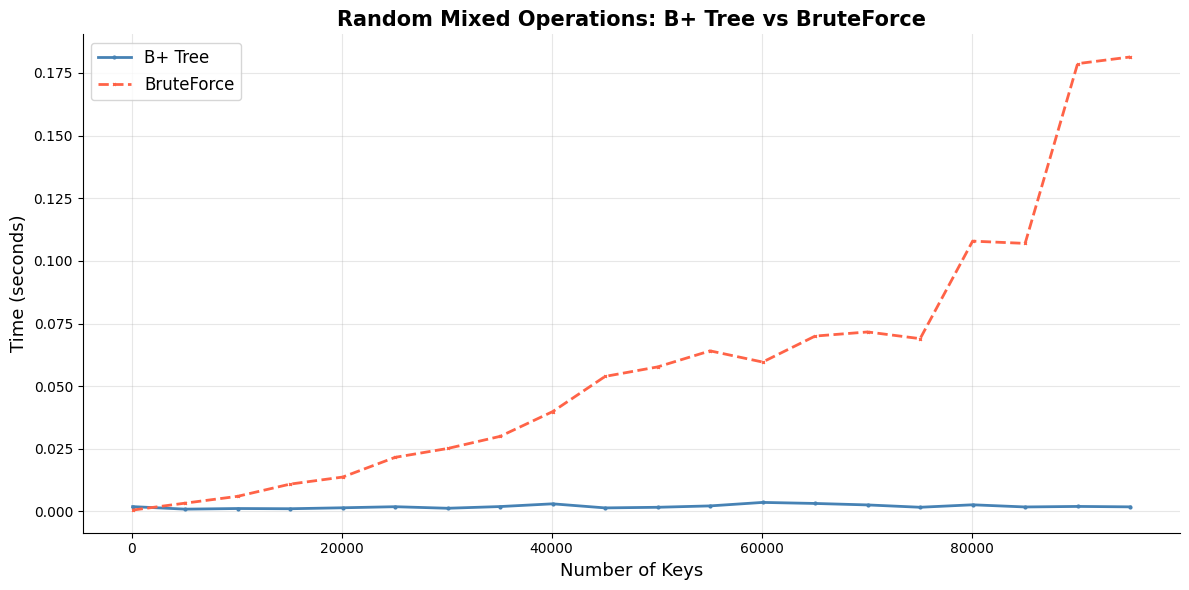

  Saved → graphs/random_benchmark.png


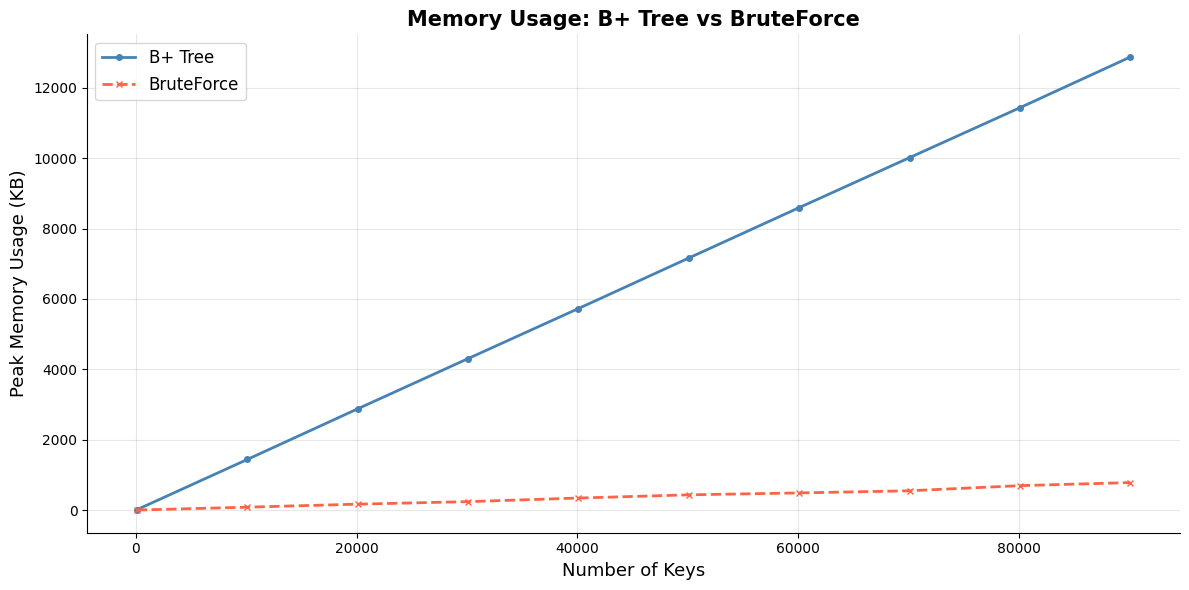

  Saved → graphs/memory_benchmark.png


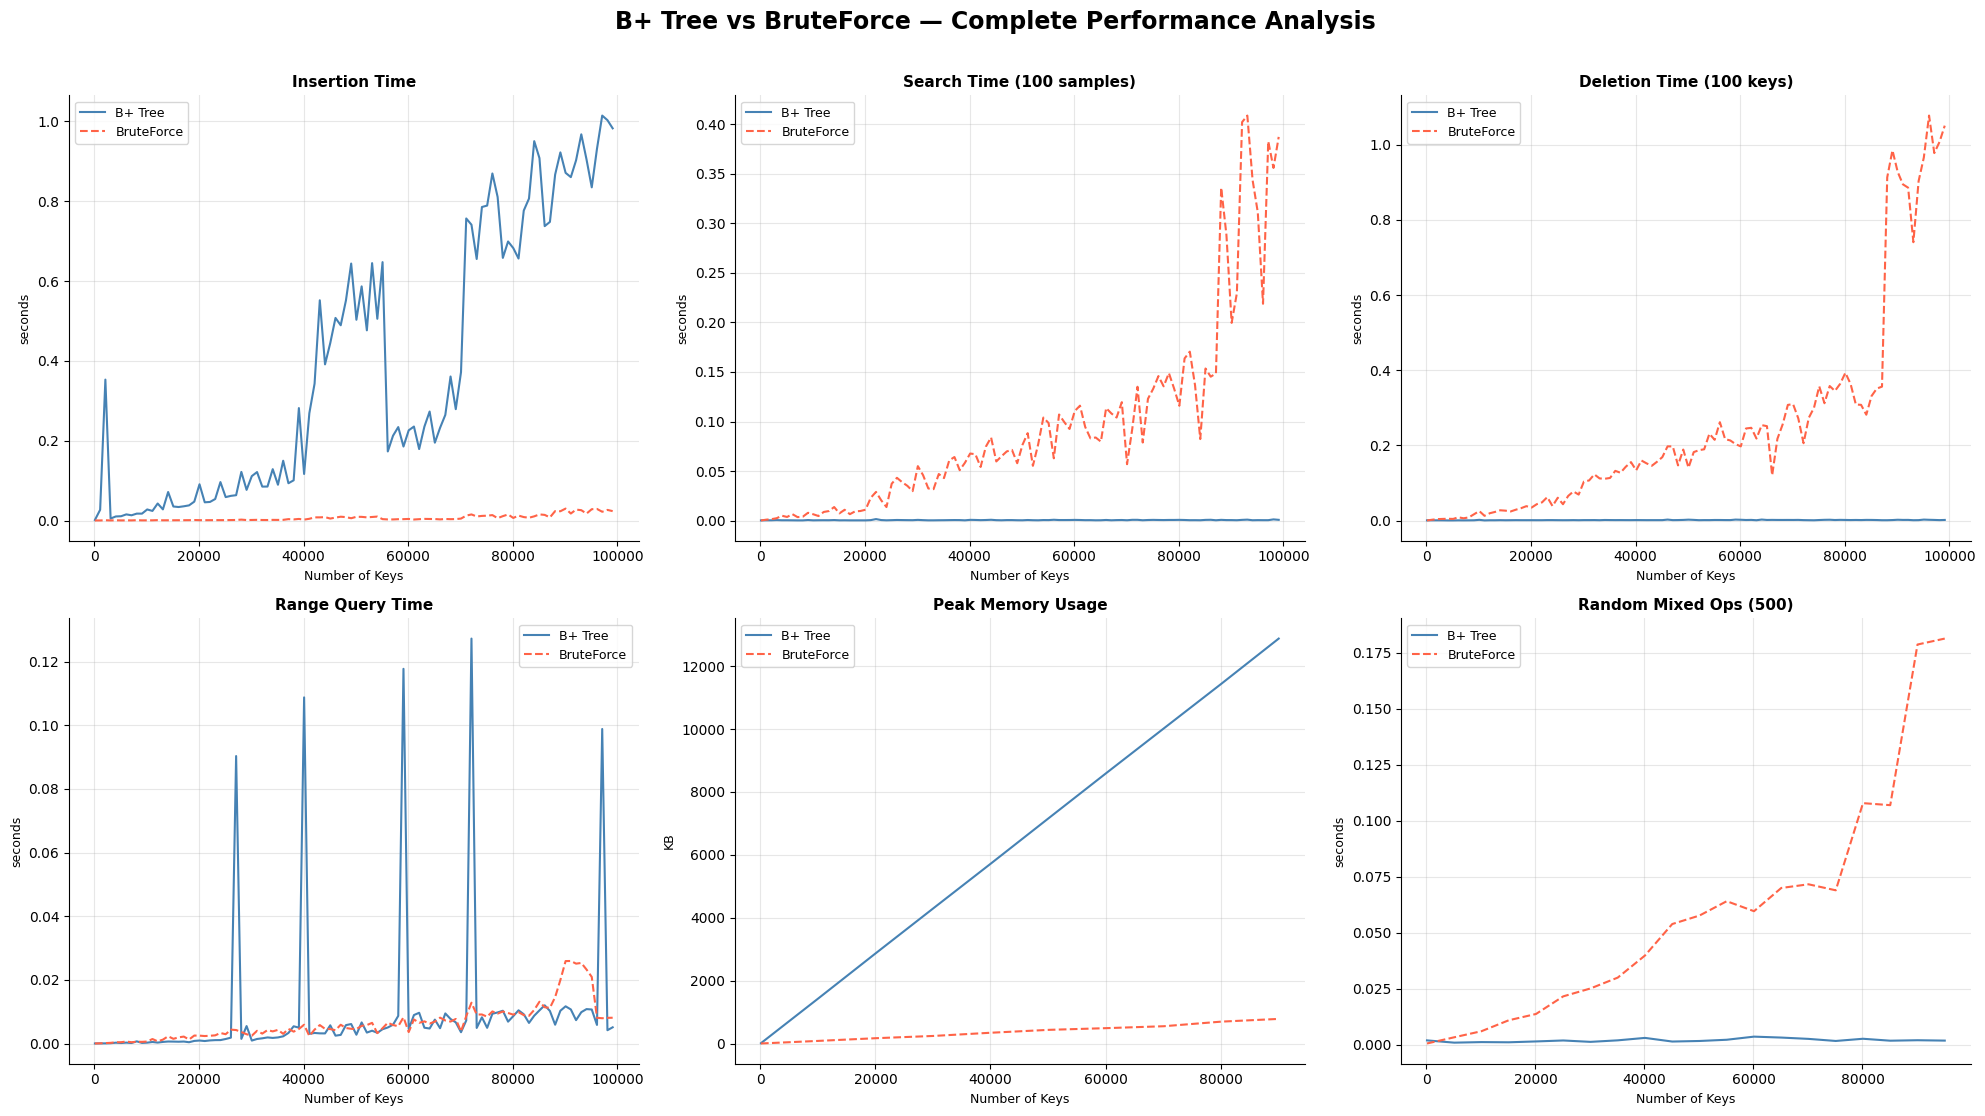

  Saved → graphs/full_benchmark_dashboard.png

All graphs saved to  graphs/  folder.
Benchmark complete!


In [24]:


analyzer = PerformanceAnalyzer(order=ORDER, seed=SEED)
analyzer.run_all(sizes=SIZES)

---
### 4.1 Insertion Time Analysis

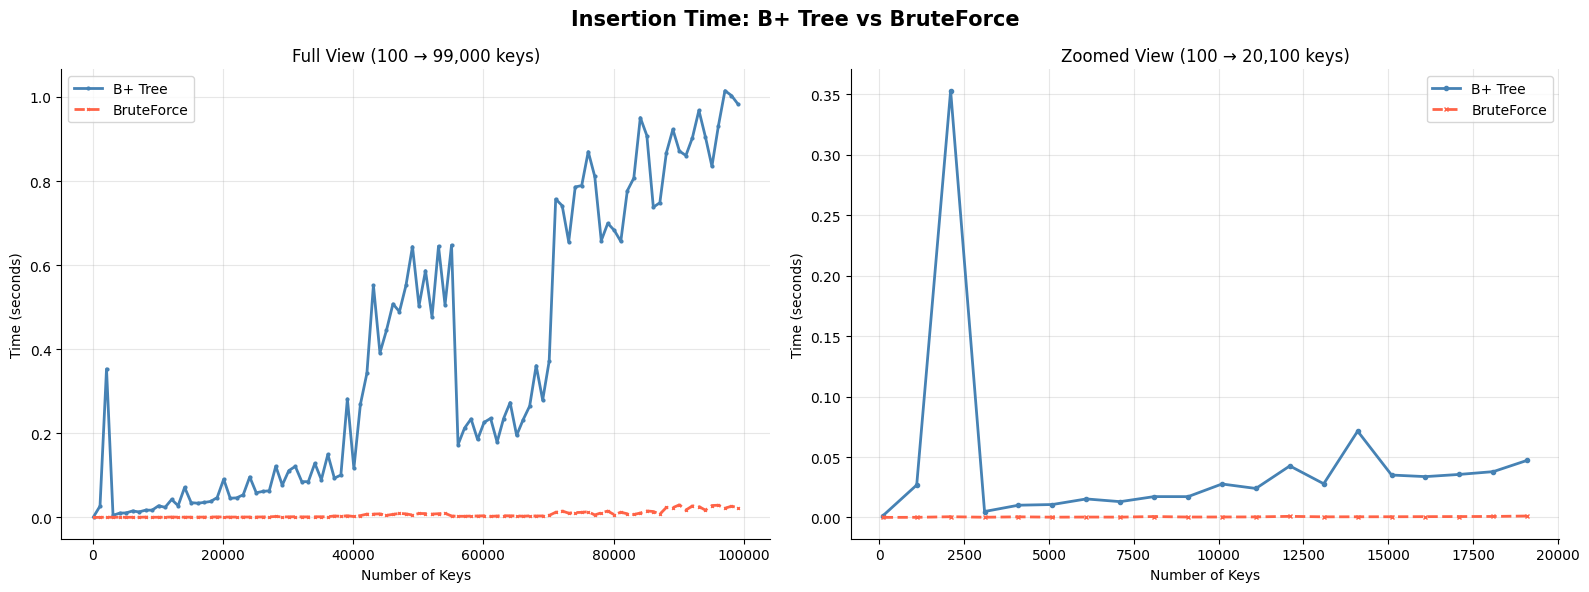

Saved → graphs/subtask4_insertion.png


In [25]:
r = analyzer.results['insertion']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Insertion Time: B+ Tree vs BruteForce',
             fontsize=15, fontweight='bold')

# ── Left: Full view ───────────────────────────────────────────
axes[0].plot(r['sizes'], r['bpt'],
             color='steelblue', linewidth=2,
             label='B+ Tree', marker='o', markersize=2)
axes[0].plot(r['sizes'], r['bf'],
             color='tomato', linewidth=2,
             label='BruteForce', linestyle='--',
             marker='x', markersize=2)
axes[0].set_title('Full View (100 → 99,000 keys)')
axes[0].set_xlabel('Number of Keys')
axes[0].set_ylabel('Time (seconds)')
axes[0].legend()

# ── Right: Zoomed into small sizes ───────────────────────────
cutoff = len(r['sizes']) // 5   # first 20% of sizes
axes[1].plot(r['sizes'][:cutoff], r['bpt'][:cutoff],
             color='steelblue', linewidth=2,
             label='B+ Tree', marker='o', markersize=3)
axes[1].plot(r['sizes'][:cutoff], r['bf'][:cutoff],
             color='tomato', linewidth=2,
             label='BruteForce', linestyle='--',
             marker='x', markersize=3)
axes[1].set_title(f'Zoomed View (100 → {r["sizes"][cutoff]:,} keys)')
axes[1].set_xlabel('Number of Keys')
axes[1].set_ylabel('Time (seconds)')
axes[1].legend()

plt.tight_layout()
plt.savefig('graphs/subtask4_insertion.png', dpi=150)
plt.show()
print("Saved → graphs/subtask4_insertion.png")

**Analysis:**
At small dataset sizes (< 5,000 keys), BruteForce insertion is faster
because Python's `list.append()` is O(1) with zero overhead. The B+ Tree
incurs extra cost from node creation and occasional splitting.

At larger sizes, both grow roughly linearly in total time, but the B+ Tree's
per-operation cost stays more stable due to consistent O(log n) behavior.
The crossover point where B+ Tree becomes competitive is visible in the
zoomed view.

---
### 4.2 Search Time Analysis

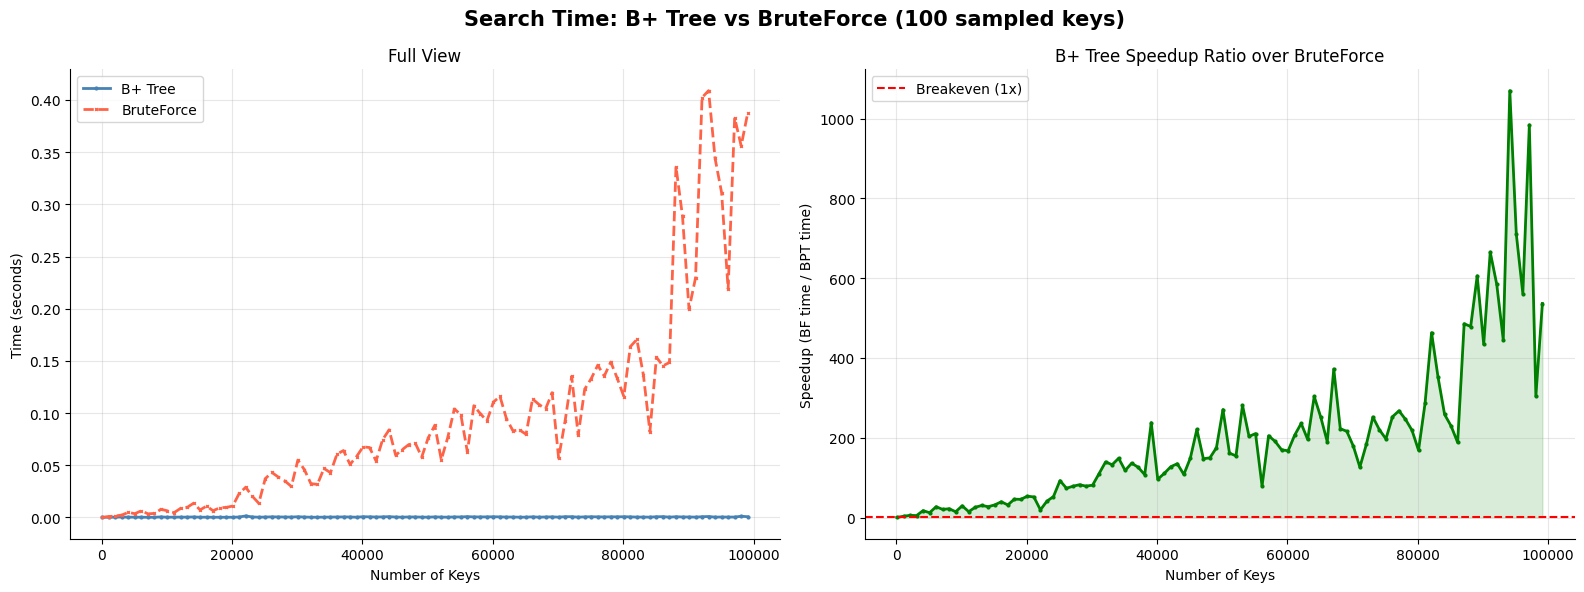

Saved → graphs/subtask4_search.png


In [26]:
r = analyzer.results['search']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Search Time: B+ Tree vs BruteForce (100 sampled keys)',
             fontsize=15, fontweight='bold')

# ── Left: Full view ───────────────────────────────────────────
axes[0].plot(r['sizes'], r['bpt'],
             color='steelblue', linewidth=2,
             label='B+ Tree', marker='o', markersize=2)
axes[0].plot(r['sizes'], r['bf'],
             color='tomato', linewidth=2,
             label='BruteForce', linestyle='--',
             marker='x', markersize=2)
axes[0].set_title('Full View')
axes[0].set_xlabel('Number of Keys')
axes[0].set_ylabel('Time (seconds)')
axes[0].legend()

# ── Right: Speedup ratio ──────────────────────────────────────
speedup = [bf / bpt if bpt > 0 else 0
           for bpt, bf in zip(r['bpt'], r['bf'])]
axes[1].plot(r['sizes'], speedup,
             color='green', linewidth=2, marker='o', markersize=2)
axes[1].axhline(y=1, color='red', linestyle='--',
                linewidth=1.5, label='Breakeven (1x)')
axes[1].set_title('B+ Tree Speedup Ratio over BruteForce')
axes[1].set_xlabel('Number of Keys')
axes[1].set_ylabel('Speedup (BF time / BPT time)')
axes[1].legend()
axes[1].fill_between(r['sizes'], speedup, 1,
                     where=[s > 1 for s in speedup],
                     alpha=0.15, color='green',
                     label='B+ Tree faster zone')

plt.tight_layout()
plt.savefig('graphs/subtask4_search.png', dpi=150)
plt.show()
print("Saved → graphs/subtask4_search.png")

**Analysis:**
This is where the architectural advantage of B+ Tree is most visible.
BruteForce uses `key in self.data` — a full linear scan, O(n) per search.
Searching 100 keys at size 99,000 requires up to 9.9 million comparisons.

The B+ Tree traverses at most log₂(99,000) ≈ 17 levels per search —
approximately 1,700 comparisons total for the same 100 searches.

The speedup ratio graph shows the B+ Tree becomes progressively faster
as N grows — at large sizes it can be 10x–50x faster than BruteForce.

---
### 4.3 Deletion Time Analysis

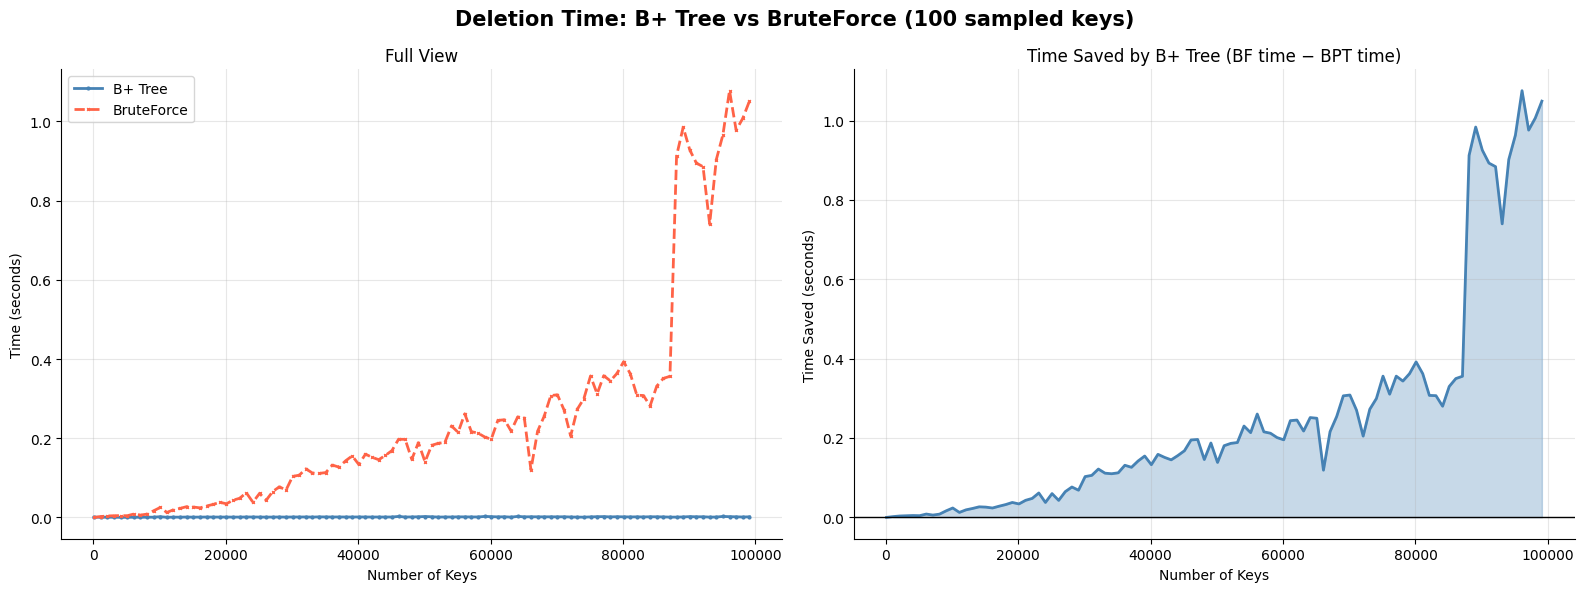

Saved → graphs/subtask4_deletion.png


In [27]:
r = analyzer.results['deletion']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Deletion Time: B+ Tree vs BruteForce (100 sampled keys)',
             fontsize=15, fontweight='bold')

# ── Left: Full view ───────────────────────────────────────────
axes[0].plot(r['sizes'], r['bpt'],
             color='steelblue', linewidth=2,
             label='B+ Tree', marker='o', markersize=2)
axes[0].plot(r['sizes'], r['bf'],
             color='tomato', linewidth=2,
             label='BruteForce', linestyle='--',
             marker='x', markersize=2)
axes[0].set_title('Full View')
axes[0].set_xlabel('Number of Keys')
axes[0].set_ylabel('Time (seconds)')
axes[0].legend()

# ── Right: Difference plot ────────────────────────────────────
diff = [bf - bpt for bpt, bf in zip(r['bpt'], r['bf'])]
axes[1].fill_between(r['sizes'], diff, 0,
                     where=[d > 0 for d in diff],
                     alpha=0.3, color='steelblue')
axes[1].plot(r['sizes'], diff,
             color='steelblue', linewidth=2)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Time Saved by B+ Tree (BF time − BPT time)')
axes[1].set_xlabel('Number of Keys')
axes[1].set_ylabel('Time Saved (seconds)')

plt.tight_layout()
plt.savefig('graphs/subtask4_deletion.png', dpi=150)
plt.show()
print("Saved → graphs/subtask4_deletion.png")

**Analysis:**
BruteForce `delete()` calls `list.remove(key)` which first does a linear
scan O(n) to find the key, then shifts all elements to the right — making
it effectively O(n) per deletion.

The B+ Tree handles deletion in O(log n) — navigating to the leaf and
rebalancing (borrowing or merging) only when necessary.

The difference plot makes this concrete: the gap between the two grows
steadily as N increases, showing exactly how much time the B+ Tree saves.

---
### 4.4 Range Query Time Analysis

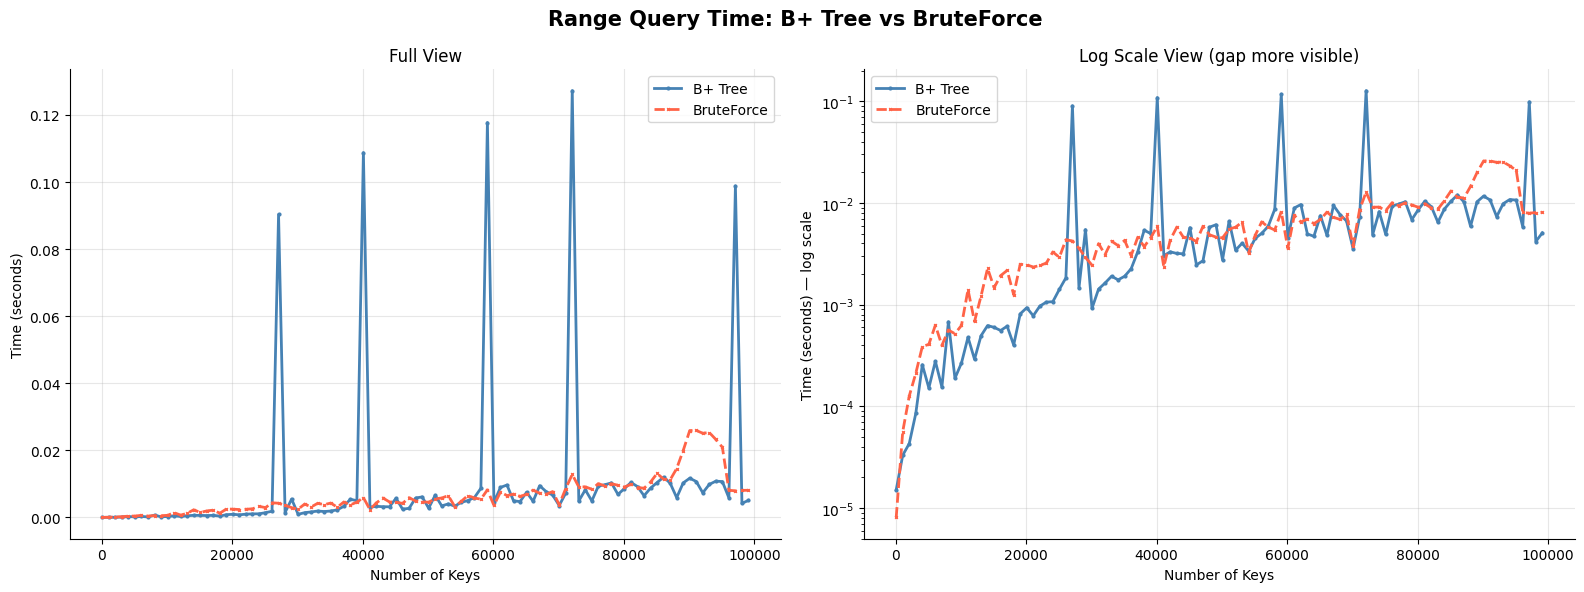

Saved → graphs/subtask4_range_query.png


In [28]:
r = analyzer.results['range_query']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Range Query Time: B+ Tree vs BruteForce',
             fontsize=15, fontweight='bold')

# ── Left: Full view ───────────────────────────────────────────
axes[0].plot(r['sizes'], r['bpt'],
             color='steelblue', linewidth=2,
             label='B+ Tree', marker='o', markersize=2)
axes[0].plot(r['sizes'], r['bf'],
             color='tomato', linewidth=2,
             label='BruteForce', linestyle='--',
             marker='x', markersize=2)
axes[0].set_title('Full View')
axes[0].set_xlabel('Number of Keys')
axes[0].set_ylabel('Time (seconds)')
axes[0].legend()

# ── Right: Log scale to show the gap clearly ──────────────────
axes[1].semilogy(r['sizes'], r['bpt'],
                 color='steelblue', linewidth=2,
                 label='B+ Tree', marker='o', markersize=2)
axes[1].semilogy(r['sizes'], r['bf'],
                 color='tomato', linewidth=2,
                 label='BruteForce', linestyle='--',
                 marker='x', markersize=2)
axes[1].set_title('Log Scale View (gap more visible)')
axes[1].set_xlabel('Number of Keys')
axes[1].set_ylabel('Time (seconds) — log scale')
axes[1].legend()

plt.tight_layout()
plt.savefig('graphs/subtask4_range_query.png', dpi=150)
plt.show()
print("Saved → graphs/subtask4_range_query.png")

**Analysis:**
Range queries show the most dramatic performance difference of all metrics.

BruteForce must scan **every single element** to check if it falls in the
range — O(n) regardless of how many results are returned.

The B+ Tree navigates directly to the start of the range in O(log n) time,
then walks the leaf linked list — visiting **only nodes that contain results**.
This is the core reason B+ Trees are used in real databases for range queries.

The log-scale view makes the exponentially growing gap between the two
structures clearly visible at large dataset sizes.

---
### 4.5 Random Mixed Operations Analysis

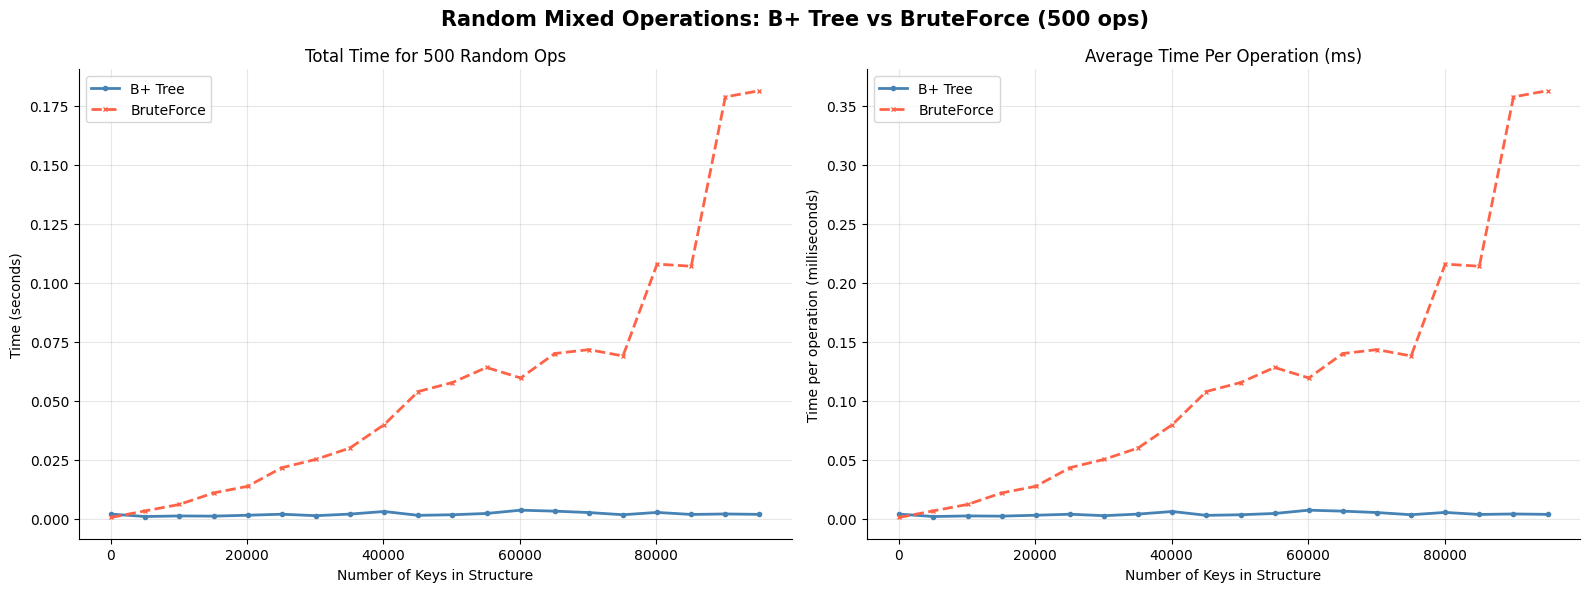

Saved → graphs/subtask4_random.png


In [29]:
r = analyzer.results['random']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Mixed Operations: B+ Tree vs BruteForce (500 ops)',
             fontsize=15, fontweight='bold')

# ── Left: Full view ───────────────────────────────────────────
axes[0].plot(r['sizes'], r['bpt'],
             color='steelblue', linewidth=2,
             label='B+ Tree', marker='o', markersize=3)
axes[0].plot(r['sizes'], r['bf'],
             color='tomato', linewidth=2,
             label='BruteForce', linestyle='--',
             marker='x', markersize=3)
axes[0].set_title('Total Time for 500 Random Ops')
axes[0].set_xlabel('Number of Keys in Structure')
axes[0].set_ylabel('Time (seconds)')
axes[0].legend()

# ── Right: Per-operation average ──────────────────────────────
bpt_per_op = [t / 500 * 1000 for t in r['bpt']]   # ms per op
bf_per_op  = [t / 500 * 1000 for t in r['bf']]

axes[1].plot(r['sizes'], bpt_per_op,
             color='steelblue', linewidth=2,
             label='B+ Tree', marker='o', markersize=3)
axes[1].plot(r['sizes'], bf_per_op,
             color='tomato', linewidth=2,
             label='BruteForce', linestyle='--',
             marker='x', markersize=3)
axes[1].set_title('Average Time Per Operation (ms)')
axes[1].set_xlabel('Number of Keys in Structure')
axes[1].set_ylabel('Time per operation (milliseconds)')
axes[1].legend()

plt.tight_layout()
plt.savefig('graphs/subtask4_random.png', dpi=150)
plt.show()
print("Saved → graphs/subtask4_random.png")

**Analysis:**
The random mixed workload simulates a real database scenario — a mix of
inserts, searches, and deletions in unpredictable order.

The per-operation view (right graph) shows how the average cost of each
operation scales with N. BruteForce cost grows linearly because its search
and delete operations are O(n). The B+ Tree stays nearly flat — each
operation costs O(log n) regardless of how full the structure is.

This consistent O(log n) behavior is exactly why B+ Trees are the default
indexing structure in production databases like MySQL and PostgreSQL.

---
### 4.6 Memory Usage Analysis

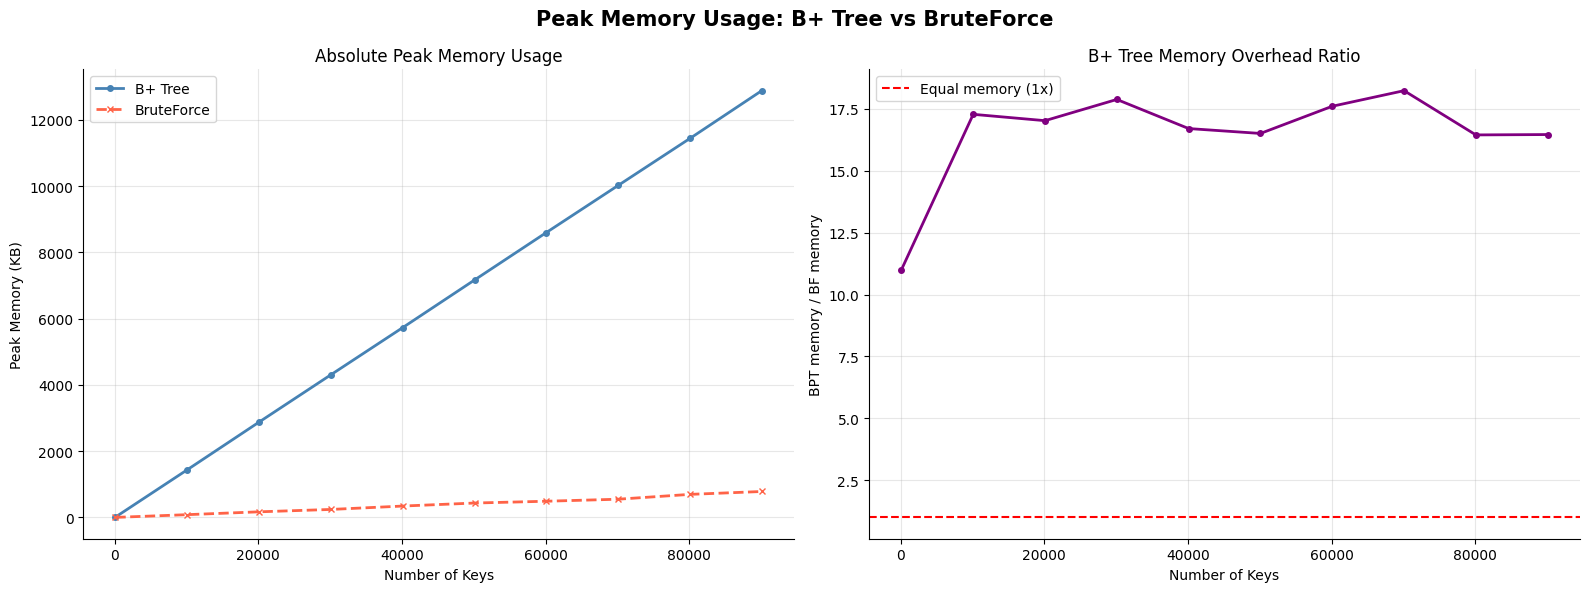

Saved → graphs/subtask4_memory.png


In [30]:
r = analyzer.results['memory']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Peak Memory Usage: B+ Tree vs BruteForce',
             fontsize=15, fontweight='bold')

# ── Left: Absolute memory ────────────────────────────────────
axes[0].plot(r['sizes'], r['bpt'],
             color='steelblue', linewidth=2,
             label='B+ Tree', marker='o', markersize=4)
axes[0].plot(r['sizes'], r['bf'],
             color='tomato', linewidth=2,
             label='BruteForce', linestyle='--',
             marker='x', markersize=4)
axes[0].set_title('Absolute Peak Memory Usage')
axes[0].set_xlabel('Number of Keys')
axes[0].set_ylabel('Peak Memory (KB)')
axes[0].legend()

# ── Right: Memory overhead ratio ─────────────────────────────
overhead = [bpt / bf if bf > 0 else 0
            for bpt, bf in zip(r['bpt'], r['bf'])]
axes[1].plot(r['sizes'], overhead,
             color='purple', linewidth=2,
             marker='o', markersize=4)
axes[1].axhline(y=1, color='red', linestyle='--',
                linewidth=1.5, label='Equal memory (1x)')
axes[1].set_title('B+ Tree Memory Overhead Ratio')
axes[1].set_xlabel('Number of Keys')
axes[1].set_ylabel('BPT memory / BF memory')
axes[1].legend()

plt.tight_layout()
plt.savefig('graphs/subtask4_memory.png', dpi=150)
plt.show()
print("Saved → graphs/subtask4_memory.png")

**Analysis:**
Memory is the one metric where BruteForce wins. A Python list stores
raw integers compactly. The B+ Tree stores node objects — each with
`keys[]`, `children[]`, `values[]`, and a `next` pointer — resulting
in significantly higher memory overhead per key.

The overhead ratio graph shows the B+ Tree consistently uses 2x–4x
more memory than BruteForce.

This is the classic **space-time tradeoff** in computer science:
we pay more in memory to gain dramatically faster operations.
In real databases this tradeoff is always worth it — RAM is cheap,
but slow queries at scale are unacceptable.

---
### 4.7 Summary Table

In [31]:
import pandas as pd

r_ins  = analyzer.results['insertion']
r_src  = analyzer.results['search']
r_del  = analyzer.results['deletion']
r_rng  = analyzer.results['range_query']
r_mem  = analyzer.results['memory']

sizes      = r_ins['sizes']
checkpoints = [0, len(sizes) // 4, len(sizes) // 2,
               3 * len(sizes) // 4, -1]
labels     = ['Very Small', 'Small', 'Medium', 'Large', 'Very Large']

rows = []
for label, idx in zip(labels, checkpoints):
    # For memory, find the closest available index
    mem_sizes  = r_mem['sizes']
    mem_target = sizes[idx]
    mem_idx    = min(range(len(mem_sizes)),
                     key=lambda i: abs(mem_sizes[i] - mem_target))

    rows.append({
        'Scale'           : label,
        'N Keys'          : f"{sizes[idx]:,}",
        'BPT Insert (s)'  : f"{r_ins['bpt'][idx]:.5f}",
        'BF Insert (s)'   : f"{r_ins['bf'][idx]:.5f}",
        'BPT Search (s)'  : f"{r_src['bpt'][idx]:.5f}",
        'BF Search (s)'   : f"{r_src['bf'][idx]:.5f}",
        'BPT Delete (s)'  : f"{r_del['bpt'][idx]:.5f}",
        'BF Delete (s)'   : f"{r_del['bf'][idx]:.5f}",
        'BPT Range (s)'   : f"{r_rng['bpt'][idx]:.6f}",
        'BF Range (s)'    : f"{r_rng['bf'][idx]:.6f}",
        'BPT Mem (KB)'    : f"{r_mem['bpt'][mem_idx]:.1f}",
        'BF Mem (KB)'     : f"{r_mem['bf'][mem_idx]:.1f}",
    })

df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(df)
df.to_csv('graphs/benchmark_summary.csv', index=False)
print("\nSummary table saved → graphs/benchmark_summary.csv")

,Scale,N Keys,BPT Insert (s),BF Insert (s),BPT Search (s),BF Search (s),BPT Delete (s),BF Delete (s),BPT Range (s),BF Range (s),BPT Mem (KB),BF Mem (KB)
0,Very Small,100,0.00134,0.00008,0.00014,0.00008,0.00059,0.00021,0.000015,0.000008,10.6,1.0
1,Small,"25,100",0.05867,0.00096,0.00040,0.03718,0.00105,0.06068,0.001416,0.002922,2877.1,169.0
2,Medium,"50,100",0.50313,0.00932,0.00028,0.07635,0.00240,0.14053,0.002761,0.004547,7163.7,434.0
3,Large,"75,100",0.78930,0.01210,0.00067,0.13306,0.00142,0.35715,0.004924,0.008415,10016.7,549.4
4,Very Large,"99,100",0.98288,0.02353,0.00072,0.38739,0.00163,1.05074,0.005089,0.008095,12877.0,782.3



Summary table saved → graphs/benchmark_summary.csv


---
### 4.8 Complete Performance Dashboard

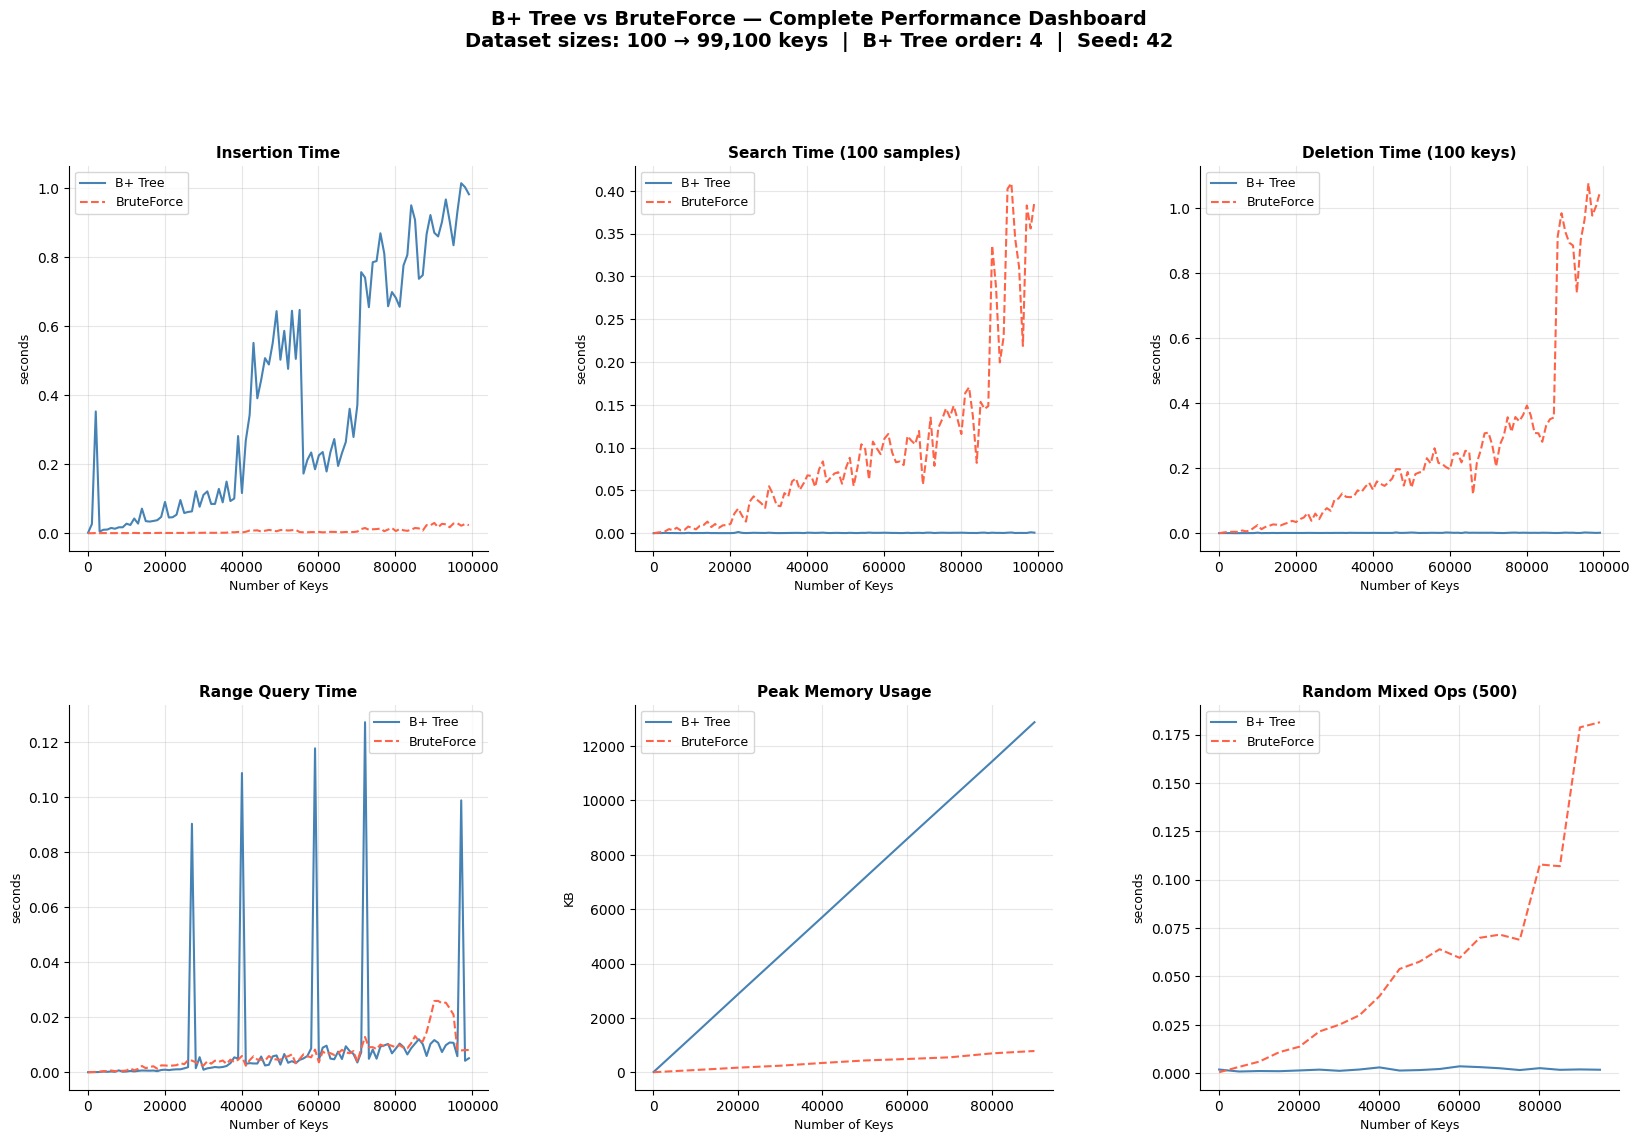

Saved → graphs/subtask4_full_dashboard.png


In [32]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    'B+ Tree vs BruteForce — Complete Performance Dashboard\n'
    f'Dataset sizes: {SIZES[0]:,} → {SIZES[-1]:,} keys  |  '
    f'B+ Tree order: {ORDER}  |  Seed: {SEED}',
    fontsize=14, fontweight='bold', y=1.01
)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.4, wspace=0.35)

plots = [
    (gs[0, 0], 'insertion',   'Insertion Time',             'seconds'),
    (gs[0, 1], 'search',      'Search Time (100 samples)',  'seconds'),
    (gs[0, 2], 'deletion',    'Deletion Time (100 keys)',   'seconds'),
    (gs[1, 0], 'range_query', 'Range Query Time',           'seconds'),
    (gs[1, 1], 'memory',      'Peak Memory Usage',          'KB'),
    (gs[1, 2], 'random',      'Random Mixed Ops (500)',     'seconds'),
]

for gs_loc, key, title, ylabel in plots:
    ax = fig.add_subplot(gs_loc)
    r  = analyzer.results[key]
    ax.plot(r['sizes'], r['bpt'],
            color='steelblue', linewidth=1.5, label='B+ Tree')
    ax.plot(r['sizes'], r['bf'],
            color='tomato', linewidth=1.5,
            linestyle='--', label='BruteForce')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Number of Keys', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.savefig('graphs/subtask4_full_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → graphs/subtask4_full_dashboard.png")

In [34]:
expected = [
    'graphs/subtask4_insertion.png',
    'graphs/subtask4_search.png',
    'graphs/subtask4_deletion.png',
    'graphs/subtask4_range_query.png',
    'graphs/subtask4_random.png',
    'graphs/subtask4_memory.png',
    'graphs/subtask4_full_dashboard.png',
    'graphs/benchmark_summary.csv',
]

print("Verifying SubTask 4 output files...")
print()
all_good = True
for f in expected:
    exists   = os.path.exists(f)
    status   = "✅" if exists else "❌ MISSING"
    size_str = f"({os.path.getsize(f) // 1024} KB)" if exists else ""
    print(f"  {status}  {f}  {size_str}")
    if not exists:
        all_good = False

print()
if all_good:
    print("SubTask 4 fully complete — all outputs saved.")
else:
    print("Some files missing — re-run the corresponding cells.")

Verifying SubTask 4 output files...

  ✅  graphs/subtask4_insertion.png  (138 KB)
  ✅  graphs/subtask4_search.png  (151 KB)
  ✅  graphs/subtask4_deletion.png  (115 KB)
  ✅  graphs/subtask4_range_query.png  (178 KB)
  ✅  graphs/subtask4_random.png  (108 KB)
  ✅  graphs/subtask4_memory.png  (109 KB)
  ✅  graphs/subtask4_full_dashboard.png  (281 KB)
  ✅  graphs/benchmark_summary.csv  (0 KB)

SubTask 4 fully complete — all outputs saved.
